# Dans cet projet nous ferons un modèle qui prédit une épidémie

## Introduction

Dans le cadre de ce projet portant sur l'analyse prédictive et la surveillance épidémiologique, l'accès aux bases de données sanitaires nationales (telles que le système DHIS2 du Ministère de la Santé) s'est heurté à des contraintes strictes de confidentialité et de sensibilité des données médicales.

Pour contourner cette limite tout en maintenant une démarche scientifique robuste, un jeu de données de **5 096 entrées** a été généré de toutes pièces. Ce volume de données a été dimensionné pour répondre aux exigences des algorithmes d'apprentissage automatique (*Machine Learning*), nécessitant un historique profond pour l'analyse prédictive.

## Description des données

Afin de refléter fidèlement la réalité épidémiologique du Burkina Faso, la base de données est structurée sous forme de **séries temporelles hebdomadaires** s'étalant sur une période de 14 ans (**de 2013 à 2026**). Elle suit un découpage géographique couvrant **7 régions sanitaires clés** du pays (le Centre, les Hauts-Bassins, le Sahel, l'Est, la Boucle du Mouhoun, les Cascades et le Centre-Nord).

Chaque ligne du jeu de données représente une semaine épidémiologique précise pour une région donnée et intègre trois grandes catégories de variables :

* **Variables Temporelles et Spatiales :** Région, Année, Semaine Épidémiologique.
* **Variables Environnementales et Climatiques (Facteurs Prédictifs) :** La pluviométrie (en mm) et la température moyenne (°C). Leurs fluctuations ont été modélisées pour respecter le climat soudano-sahélien (saison des pluies de juin à octobre, pics de chaleur en mars/avril).
* **Variables de Riposte et Sanitaires (Variables Cibles) :** Le taux de couverture en moustiquaires (MILDA), l'activation des campagnes vaccinales, ainsi que le nombre de cas hebdomadaires de **Paludisme** et de **Dengue**.

### 3.3. Intégration des Dynamiques Épidémiques Spécifiques

Pour garantir la pertinence des modèles prédictifs, des règles logiques et médicales strictes ont été injectées lors de la modélisation :

1. **Saisonnalité du Paludisme :** Le nombre de cas d'anophèles et de transmissions du paludisme est programmé pour exploser systématiquement entre juillet et novembre, simulant fidèlement l'impact de la mousson au Burkina Faso.
2. **Spécificité Urbaine de la Dengue :** Le modèle applique une forte prévalence de la dengue dans les centres urbains (Régions du Centre et des Hauts-Bassins) et intègre des anomalies épidémiques majeures, reproduisant notamment la grande crise sanitaire historique de l'année 2023.

### 3.4. Traitement, Nettoyage et Standardisation

Bien que généré de manière algorithmique, l'ensemble du jeu de données a subi un processus rigoureux de nettoyage et de standardisation. Toutes les variables, libellés et formats ont été entièrement traduits et encodés en français standardisé.

Cette étape de traitement est doublement cruciale : elle standardise les données pour l'analyse statistique sous Python (via la bibliothèque *Pandas*) et prépare l'environnement pour l'intégration future d'un système de type "Chatbot". Ce dernier pourra ainsi requêter une base de données propre, claire et parfaitement alignée avec le langage des utilisateurs francophones et des professionnels de la santé au Burkina Faso.



### Importation des packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Prétraitement 

In [2]:
# importation de nos données
data = pd.read_csv("surveillance_sanitaire_bf.csv")
data.head()

,Region,Annee,Semaine_Epi,Pluviometrie_mm,Temperature_Moy_C,Taux_Couverture_MILDA,Campagne_Vaccinale_Active,Cas_Paludisme,Cas_Dengue
0,Centre (Ouaga),2013,1,1.1,28.3,84.6,0,592,7
1,Centre (Ouaga),2013,2,4.9,26.6,90.7,0,573,18
2,Centre (Ouaga),2013,3,1.5,28.2,76.0,0,388,27
3,Centre (Ouaga),2013,4,2.2,29.5,93.5,0,409,22
4,Centre (Ouaga),2013,5,0.2,26.0,79.7,0,369,21


### Apperçu des données

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5096 entries, 0 to 5095
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region                     5096 non-null   str    
 1   Annee                      5096 non-null   int64  
 2   Semaine_Epi                5096 non-null   int64  
 3   Pluviometrie_mm            5096 non-null   float64
 4   Temperature_Moy_C          5096 non-null   float64
 5   Taux_Couverture_MILDA      5096 non-null   float64
 6   Campagne_Vaccinale_Active  5096 non-null   int64  
 7   Cas_Paludisme              5096 non-null   int64  
 8   Cas_Dengue                 5096 non-null   int64  
dtypes: float64(3), int64(5), str(1)
memory usage: 413.9 KB


In [4]:
data.describe()

,Annee,Semaine_Epi,Pluviometrie_mm,Temperature_Moy_C,Taux_Couverture_MILDA,Campagne_Vaccinale_Active,Cas_Paludisme,Cas_Dengue
count,5096.000000,5096.000000,5096.000000,5096.000000,5096.000000,5096.000000,5096.000000,5096.000000
mean,2019.500000,26.500000,25.145663,30.457947,85.004945,0.016484,765.372645,21.451334
std,4.031524,15.009804,35.452627,3.904113,5.760981,0.127338,664.414682,83.368734
min,2013.000000,1.000000,0.000000,25.000000,75.000000,0.000000,133.000000,0.000000
25%,2016.000000,13.750000,1.900000,27.400000,80.100000,0.000000,245.000000,5.000000
50%,2019.500000,26.500000,3.900000,29.800000,85.000000,0.000000,377.000000,9.000000
75%,2023.000000,39.250000,42.600000,32.200000,90.000000,0.000000,1249.250000,13.000000
max,2026.000000,52.000000,120.000000,41.000000,95.000000,1.000000,2977.000000,1479.000000


In [6]:
data.isnull().sum()

Region                       0
Annee                        0
Semaine_Epi                  0
Pluviometrie_mm              0
Temperature_Moy_C            0
Taux_Couverture_MILDA        0
Campagne_Vaccinale_Active    0
Cas_Paludisme                0
Cas_Dengue                   0
dtype: int64

### Néttoyage de nos donnée

In [7]:
print("Valeurs uniques de Campagne_Vaccinale_Active :", data['Campagne_Vaccinale_Active'].unique())

Valeurs uniques de Campagne_Vaccinale_Active : [0 1]


In [8]:
# Vérifier les valeurs extrêmes
print("\nQuantiles pour Cas_Paludisme :")
print(data['Cas_Paludisme'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("\nQuantiles pour Cas_Dengue :")
print(data['Cas_Dengue'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))


Quantiles pour Cas_Paludisme :
0.25     245.00
0.50     377.00
0.75    1249.25
0.95    2144.25
0.99    2625.05
Name: Cas_Paludisme, dtype: float64

Quantiles pour Cas_Dengue :
0.25      5.00
0.50      9.00
0.75     13.00
0.95     32.25
0.99    343.15
Name: Cas_Dengue, dtype: float64


In [9]:
# Vérifier les doublons
duplicates = data[data.duplicated(subset=['Region', 'Annee', 'Semaine_Epi'], keep=False)]
print(f"\nNombre de doublons potentiels : {len(duplicates)}")
if len(duplicates) > 0:
    print(duplicates)


Nombre de doublons potentiels : 0


### Gestion des valeurs manquantes

In [10]:
# Pourcentage de valeurs manquantes par colonne
valeur_nul = data.isnull().sum() / len(data) * 100
print("\nPourcentage de valeurs manquantes par colonne :")
print(valeur_nul[valeur_nul > 0])


Pourcentage de valeurs manquantes par colonne :
Series([], dtype: float64)


### correction des noms des colonnes pour faciliter le traitement

In [11]:
# Renommer les colonnes
data.columns = data.columns.str.lower().str.replace(' ', '_')
# Si nécessaire, remplacer les caractères spéciaux
data.columns = data.columns.str.replace('é', 'e').str.replace('è', 'e').str.replace('ê', 'e')
print("\nNoms des colonnes après nettoyage :")
print(data.columns.tolist())


Noms des colonnes après nettoyage :
['region', 'annee', 'semaine_epi', 'pluviometrie_mm', 'temperature_moy_c', 'taux_couverture_milda', 'campagne_vaccinale_active', 'cas_paludisme', 'cas_dengue']


In [12]:
# Fonction pour convertir semaine épi en date approximative
def epiweek_to_date(year, week):
    # Semaine 1 commence le premier lundi de l'année (approximation)
    # On utilise une méthode simple : on ajoute (week-1)*7 jours au 1er janvier
    from datetime import datetime, timedelta
    first_day = datetime(year, 1, 1)
    # Trouver le premier lundi de l'année
    days_to_monday = (7 - first_day.weekday()) % 7
    first_monday = first_day + timedelta(days=days_to_monday)
    # Ajouter les semaines
    approx_date = first_monday + timedelta(weeks=week-1)
    return approx_date

# Appliquer la fonction
data['date_approx'] = data.apply(lambda row: epiweek_to_date(row['annee'], row['semaine_epi']), axis=1)
print("\nAperçu des dates :")
print(data[['annee', 'semaine_epi', 'date_approx']].head())


Aperçu des dates :
   annee  semaine_epi date_approx
0   2013            1  2013-01-07
1   2013            2  2013-01-14
2   2013            3  2013-01-21
3   2013            4  2013-01-28
4   2013            5  2013-02-04


### Création de variable saisonnière

In [13]:
# Extraire le mois de la date approximative
data['mois'] = data['date_approx'].dt.month
# Créer une colonne saison (approximative)
data['saison'] = data['mois'].apply(lambda m: 'Pluvieuse' if 5 <= m <= 10 else 'Sèche')
print("\nDistribution des saisons :")
print(data['saison'].value_counts())


Distribution des saisons :
saison
Pluvieuse    2576
Sèche        2520
Name: count, dtype: int64


In [14]:
# Sélectionner les colonnes à standardiser
numeric_cols = ['pluviometrie_mm', 'temperature_moy_c', 'taux_couverture_milda']
# Copier les données pour éviter de modifier l'original
data = data.copy()
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
# Maintenant, df_scaled contient les valeurs standardisées

In [15]:
data.head()

,region,annee,semaine_epi,pluviometrie_mm,temperature_moy_c,taux_couverture_milda,campagne_vaccinale_active,cas_paludisme,cas_dengue,date_approx,mois,saison
0,Centre (Ouaga),2013,1,-0.678314,-0.552791,-0.070298,0,592,7,2013-01-07,1,Sèche
1,Centre (Ouaga),2013,2,-0.571118,-0.988272,0.988654,0,573,18,2013-01-14,1,Sèche
2,Centre (Ouaga),2013,3,-0.667030,-0.578408,-1.563246,0,388,27,2013-01-21,1,Sèche
3,Centre (Ouaga),2013,4,-0.647284,-0.245393,1.474730,0,409,22,2013-01-28,1,Sèche
4,Centre (Ouaga),2013,5,-0.703703,-1.141971,-0.920931,0,369,21,2013-02-04,2,Sèche


In [16]:
# Sauvegarder le DataFrame nettoyé et standardiser
data.to_csv('surveillance_sanitaire_nettoyer.csv', index=False)

print("\n Prétraitement terminé ! Fichiers sauvegardés.")


 Prétraitement terminé ! Fichiers sauvegardés.


### Analyse exploratoire

In [17]:
# Importation des données nettoyées pour
data = pd.read_csv('surveillance_sanitaire_nettoyer.csv')

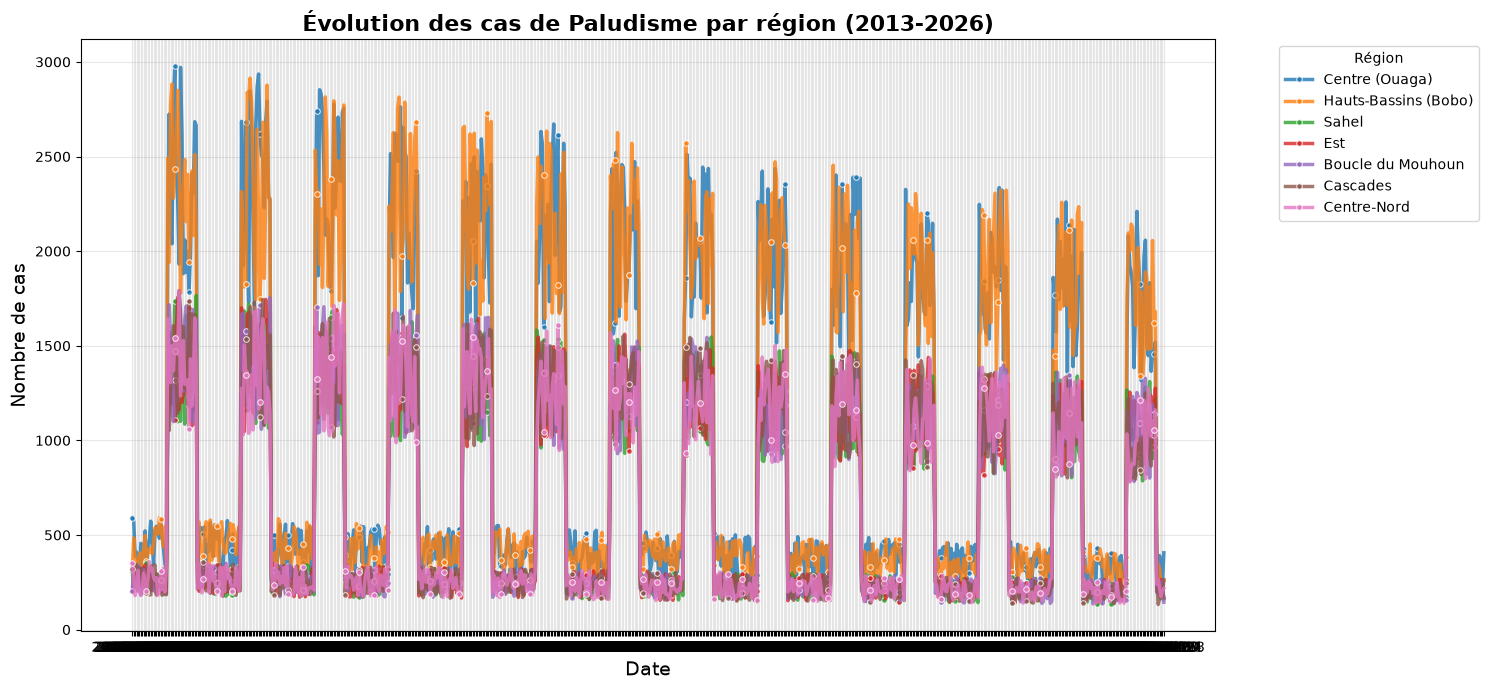

<Figure size 640x480 with 0 Axes>

In [18]:
# Graphique 1 : Évolution des cas de Paludisme par région
plt.figure(figsize=(15, 7))
sns.lineplot(
    data=data,
    x='date_approx',  # À créer si nécessaire
    y='cas_paludisme',
    hue='region',
    linewidth=2.5,
    alpha=0.8,
    marker='o',
    markersize=4,
    markevery=10  # Afficher un point sur 10 pour éviter la surcharge
)
plt.title('Évolution des cas de Paludisme par région (2013-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Nombre de cas', fontsize=14)
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('figure.png', dpi=300, bbox_inches='tight')

## Interprétation du Graphique : Analyse des Tendances Pluriannuelles et Saisonnieres du Paludisme

L’examen de cette série temporelle historique met en évidence deux dynamiques majeures qui régissent le paludisme au Burkina Faso :

### 1. Une Saisonnalité Strictement Prévisible (Le comportement annuel)

* **Observation :** Chaque année, sans aucune exception, la courbe adopte un profil en "créneaux" ou en dents de scie bien spécifiques. On observe un plateau bas et stable (entre 200 et 500 cas) au cours des premiers mois de l’année, suivi d'une hausse verticale et brutale pour former un pic massif (allant de 1 500 à près de 3 000 cas) au cours de la seconde moitié de l'année.
* **Interprétation :** Ce rythme immuable traduit la dépendance absolue du paludisme vis-à-vis du calendrier climatique sahélien. La phase basse correspond à la saison sèche (facteur limitant pour la reproduction des vecteurs) tandis que les sommets annuels matérialisent l'hivernage. Toutes les régions du pays entrent en phase épidémique au même moment de l'année.

### 2. Une Tendance Globale à la Baisse (L'évolution à long terme)

* **Observation :** En observant les sommets des pics d'une année à l'autre (notamment de 2013 à 2026), on remarque une **décroissance progressive de la hauteur des pics**. Alors qu'en 2013, 2014 et 2015, les sommets dépassaient fréquemment les 2 800 cas hebdomadaires pour le Centre et les Hauts-Bassins, ils se situent nettement plus bas à partir de 2024, oscillant sous la barre des 2 200 cas en 2025 et 2026.
* **Interprétation :** C'est une donnée fondamentale pour ton projet. Cette baisse à long terme met en lumière l'**efficacité progressive des politiques publiques de santé** menées au Burkina Faso. Cette régression du fardeau épidémique lors des pics s'explique par l'intensification des campagnes de Chimioprévention du Paludisme Saisonnier (CPS), le taux de couverture croissant en moustiquaires (MILDA), et plus récemment, l'impact de l'introduction à grande échelle de la vaccination contre le paludisme à partir de 2024-2025.

---

> *"Cette série temporelle de longue durée montre que le paludisme au Burkina Faso combine deux forces : une composante cyclique (saisonnière) et une tendance structurelle baissière. Pour notre **modèle prédictif**, cette baisse à long terme est une opportunité d'évaluation. En intégrant des variables institutionnelles (comme `Campagne_Vaccinale_Active` ou `Taux_Couverture_MILDA`), nos algorithmes ne se contentent pas de prédire les cas d'après la météo ; ils parviennent à quantifier mathématiquement le nombre de cas évités grâce aux vaccins et aux moustiquaires au fil des ans."*

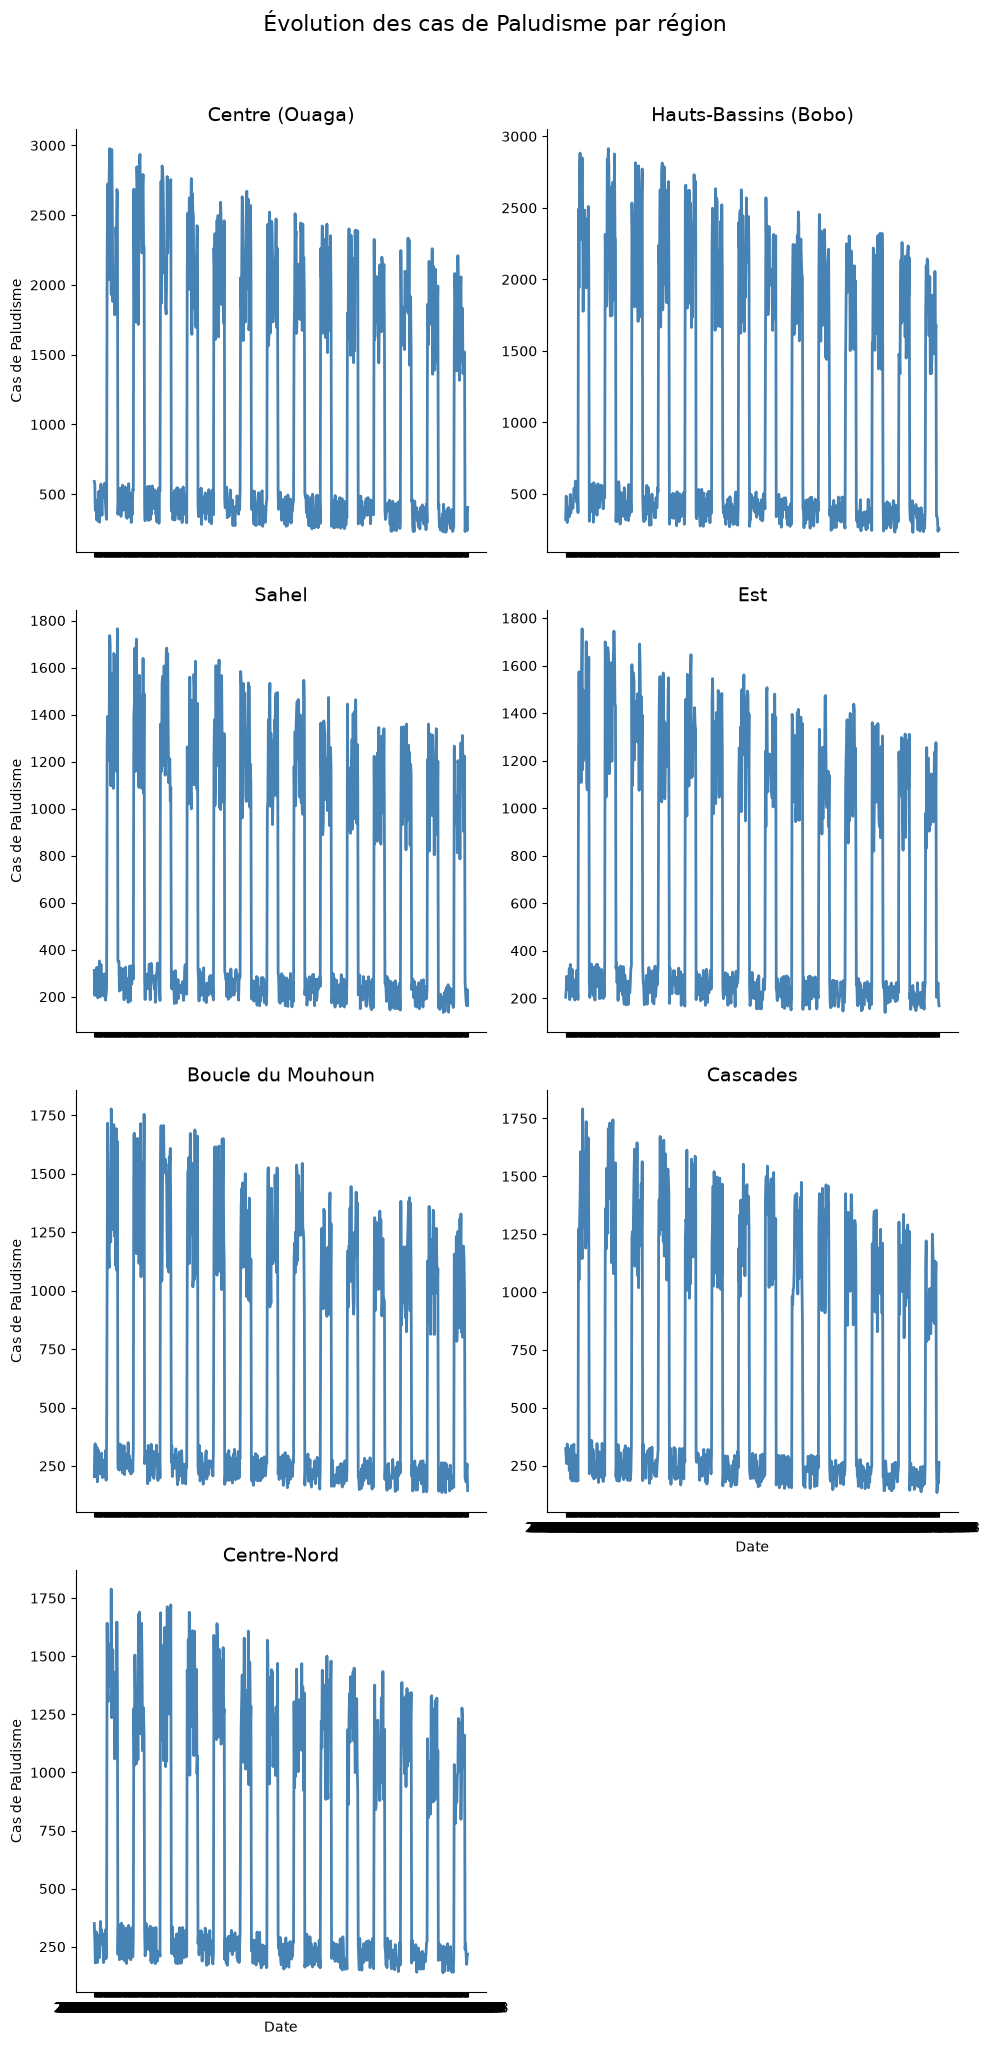

In [18]:
# Graphique 1b : FacetGrid pour comparer les régions
g = sns.FacetGrid(data, col='region', col_wrap=2, height=5, sharey=False)
g.map_dataframe(sns.lineplot, x='date_approx', y='cas_paludisme', color='steelblue', linewidth=2)
g.set_axis_labels('Date', 'Cas de Paludisme')
g.set_titles(col_template='{col_name}', size=14)
g.fig.suptitle('Évolution des cas de Paludisme par région', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Interprétation des Séries Temporelles Individualisées par Région

L'individualisation des courbes permet de valider simultanément deux comportements épidémiologiques : une tendance nationale commune et des échelles de gravité locales bien distinctes.

### 1. Une Décroissance Structurelle Commune à l'Échelle Nationale

* **Observation :** Dans les 7 graphiques, sans aucune exception, la "ligne de crête" (formée par le sommet des pics annuels) s'oriente vers le bas au fil des années (de 2013 à 2026).
* **Interprétation :** Cela prouve que la tendance à la baisse observée de façon globale n'est pas le résultat d'une amélioration isolée dans une seule région, mais qu'elle est **généralisée à tout le territoire national**. Les programmes de lutte contre le paludisme (distributions universelles de MILDA, campagnes de CPS et intégration de la vaccination) portent leurs fruits de manière homogène à travers tout le Burkina Faso.

### 2. Une Différence Majeure d'Échelle (Le volume de la charge sanitaire)

C'est ici que l'hétérogénéité spatiale saute aux yeux si l'on regarde attentivement l'axe des ordonnées ($Y$) :

* **Les Pôles de Haute Densité (Centre et Hauts-Bassins) :** L'axe des ordonnées grimpe jusqu'à **3 000 cas** par semaine. Les pics y sont massifs et très larges.
* **Les Autres Régions (Sahel, Est, Mouhoun, Cascades, Centre-Nord) :** L'axe des ordonnées est plafonné à **1 800 cas** maximum. Leurs pics les plus hauts (en 2013) n'atteignent même pas le niveau des pics les plus bas du Centre en 2026.
* **Interprétation :** Les facteurs environnementaux locaux et la taille de la population modifient l'échelle du fardeau. Bien que la dynamique temporelle (le rythme) soit identique partout, l'intensité épidémique est quasiment doublée dans les grands centres urbains par rapport aux régions périphériques ou rurales.

---

> *"Cette grille de graphiques justifie pleinement l'utilisation de modèles prédictifs régionalisés. On y voit clairement que le comportement temporel est le même partout, mais que l'amplitude des cas varie du simple au double selon la région. Face à ce constat, notre architecture de prédiction a deux choix possibles, tous deux robustes : soit **entraîner un modèle unique global** en fournissant la variable `Region` sous forme d'encodage (One-Hot Encoding) pour que l'algorithme apprenne ces différences d'échelles, soit **déployer 7 sous-modèles prédictifs indépendants** (un par région), garantissant ainsi une précision maximale pour les alertes sanitaires locales."*

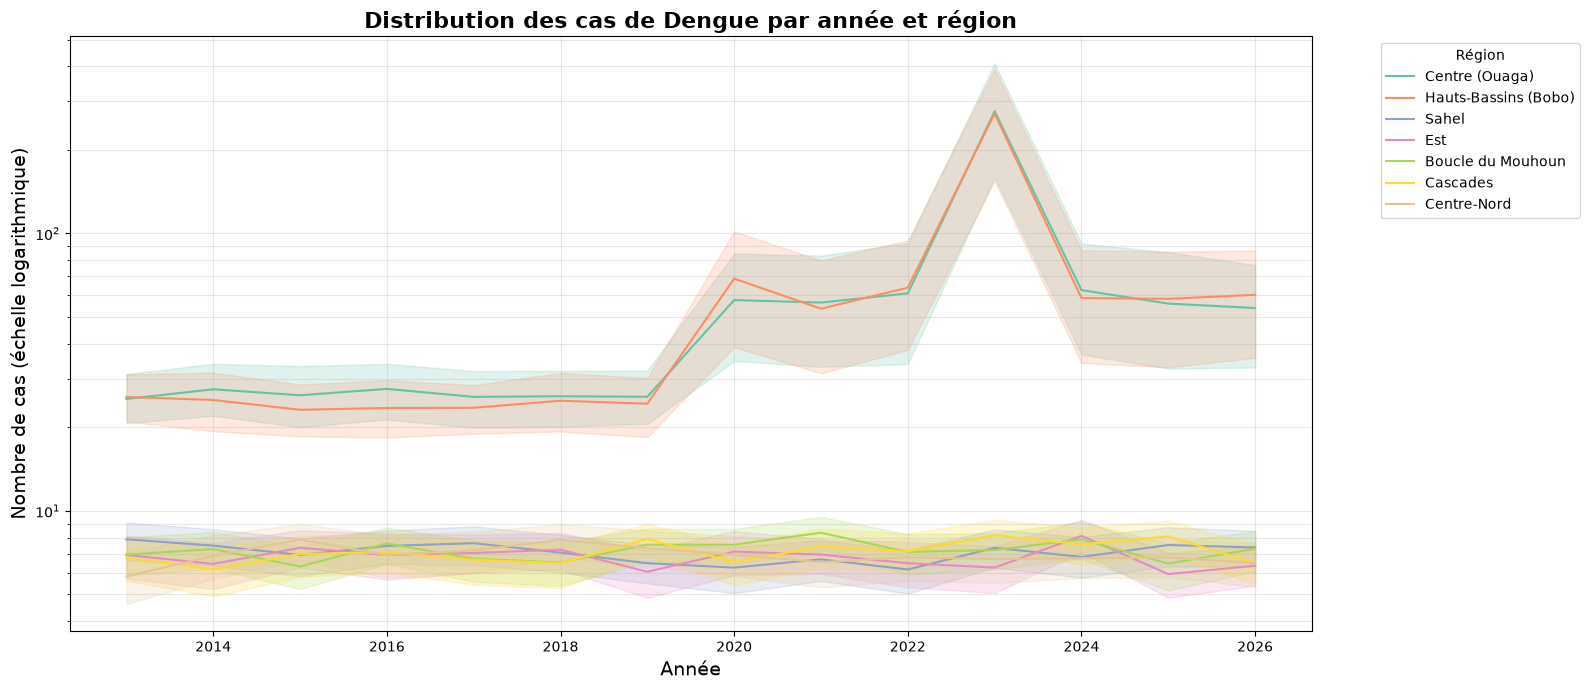

In [19]:
# Graphique 2 : line des cas de Dengue
plt.figure(figsize=(16, 7))
sns.lineplot(
    data=data,
    x='annee',
    y='cas_dengue',
    hue='region',
    palette='Set2',
    linewidth=1.5,
)
plt.title('Distribution des cas de Dengue par année et région', fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=14)
plt.ylabel('Nombre de cas (échelle logarithmique)', fontsize=14)
plt.yscale('log')  # Échelle log car les valeurs sont très dispersées
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Interprétation du Graphique : Évolution Annuelle de la Dengue et Rupture Épidémique

Ce graphique présente l'évolution de la moyenne annuelle des cas de dengue par région de 2013 à 2026. Les bandes semi-transparentes représentent l'intervalle de confiance (la variabilité des cas au cours de l'année). L'analyse montre une **bipolarisation territoriale nette** et une modification profonde de la dynamique temporelle.

### 1. La Bipolarisation Territoriale Permanente (La fracture Urbain vs Rural)

* **Observation :** Le graphique se divise très nettement en deux blocs qui ne se croisent jamais :
* **Le bloc supérieur :** Constitué du **Centre (Ouaga)** en vert et des **Hauts-Bassins (Bobo)** en orange. Ils se situent constamment au-dessus du seuil des 20 cas annuels moyens.
* **Le bloc inférieur :** Regroupant toutes les autres régions (Sahel, Est, Cascades, etc.), qui stagnent de manière linéaire en bas du graphique, oscillant faiblement entre 5 et 10 cas par an.


* **Interprétation :** Cela confirme de manière structurelle que le risque lié à la dengue est un phénomène circonscrit aux grands centres urbains au Burkina Faso. Dans les régions à dominante rurale ou semi-aride, la maladie ne parvient pas à s'installer sous forme épidémique majeure à cause du manque de gîtes larvaires artificiels denses nécessaires au moustique *Aedes aegypti*.

### 2. La Chronologie d'une Endémisation (2013 - 2022)

* **Observation :** Entre 2013 et 2019, la situation est stable dans les deux grandes villes (environ 25-30 cas en moyenne). En **2020**, on observe une première marche ascendante où la moyenne double brusquement pour s'installer durablement autour de 50 à 60 cas moyens jusqu'en 2022.
* **Interprétation :** Cette évolution montre que la dengue est passée d'un statut de maladie émergente sporadique à un statut de **maladie endémo-épidémique urbaine installée**. Les conditions urbaines (gestion des déchets, stockage d'eau) ont permis au virus de maintenir une circulation de fond de plus en plus élevée.

### 3. Le Point de Rupture Majeur : L'Épidémie Flamboyante de 2023

* **Observation :** L'année 2023 est marquée par un pic vertical spectaculaire où le Centre et les Hauts-Bassins rompent complètement leurs dynamiques pour frôler une moyenne de **500 cas** (une multiplication par près de 10 par rapport à l'année précédente). L'enveloppe de variance est aussi la plus large, traduisant la violence des vagues hebdomadaires au cours de cette année-là.
* **Interprétation :** C'est la signature statistique de la crise sanitaire majeure de la dengue en 2023. Le graphique montre bien qu'après ce choc, en 2024, 2025 et 2026, les courbes redescendent mais **stabilisent à un niveau supérieur** à celui d'avant 2020. L'épidémie de 2023 a laissé des traces : le virus est désormais solidement implanté.

---

> *"Ce graphique en échelle logarithmique montre que la dengue au Burkina Faso a changé de régime statistique à deux reprises : une première fois en 2020 avec une hausse du bruit de fond, et une seconde fois en 2023 avec une rupture épidémique historique. Pour l'**analyse prédictive**, cela prouve que des modèles basés sur de simples moyennes passées seraient incapables d'anticiper ces changements de comportement. Nos algorithmes de Machine Learning doivent intégrer des variables de contexte annuel (comme les anomalies de température ou de cumuls pluviométriques d'une année sur l'autre) pour détecter ces signaux faibles avant que la courbe ne bascule vers une explosion épidémique."*

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2604\113311209.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


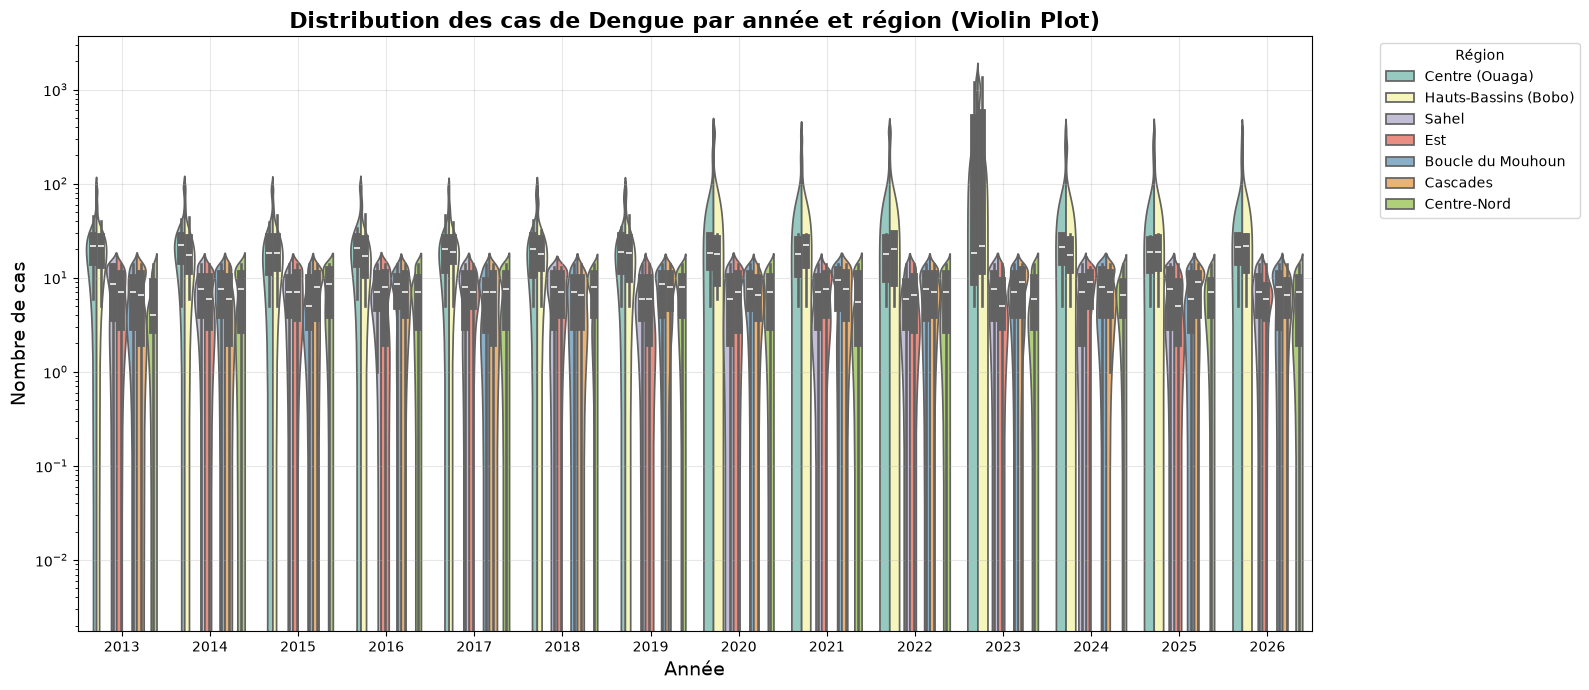

In [20]:
# Version violin plot pour mieux voir la distribution
plt.figure(figsize=(16, 7))
sns.violinplot(
    data=data,
    x='annee',
    y='cas_dengue',
    hue='region',
    split=True,  # Diviser les violons par région
    palette='Set3',
    scale='width'
)
plt.title('Distribution des cas de Dengue par année et région (Violin Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=14)
plt.ylabel('Nombre de cas', fontsize=14)
plt.yscale('log')
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interprétation du Violin Plot : Profil de Distribution Globale de la Dengue

Ce graphique permet de comprendre la structure profonde des vagues de dengue au Burkina Faso de 2013 à 2026 en combinant la distribution annuelle et la comparaison régionale.

### 1. La forme en "goutte inversée" : La signature des maladies à pics épidémiques

* **Observation :** Pour les deux régions majeures—le **Centre** (vert d'eau) et les **Hauts-Bassins** (jaune clair)—les violons ont une base très large et ventrue située entre $10^1$ (10 cas) et $3 \times 10^1$ (30 cas), qui s'étire vers le haut en un col très fin et allongé.
* **Interprétation :** Cette forme spécifique montre que la dengue passe la grande majorité de l'année à un niveau très bas (la base ventrue où s'accumulent la plupart des semaines épidémiologiques). Les cols fins qui s'élancent vers les sommets représentent les quelques semaines de l'année où surviennent les flambées brutales. C'est le comportement typique d'une maladie à **dynamique explosive mais courte**.

### 2. La confirmation de l'asymétrie territoriale (Urbain vs Rural)

* **Observation :** Les violons des autres régions (Sahel, Est, Boucle du Mouhoun, Cascades, Centre-Nord) ressemblent à de petits bâtons ou à des violons aplatis, totalement écrasés sous la barre des 10 cas ($10^1$), et ce, de 2013 à 2026.
* **Interprétation :** L'absence de col allongé chez ces régions rurales prouve qu'elles ne subissent jamais de vagues épidémiques de dengue, contrairement au milieu urbain. La distribution y est extrêmement resserrée et stable à un niveau quasi nul.

### 3. L'évolution temporelle de la forme des violons

Si l'on regarde la chronologie des deux régions urbaines (Centre et Hauts-Bassins) :

* **Période 2013-2019 :** La base des violons est située un peu plus bas, et le sommet des cols dépasse rarement les 100 cas ($10^2$).
* **Période 2020-2022 :** On remarque que tout le corps du violon (la boîte noire centrale et la base ventrue) migre légèrement vers le haut. Le "bruit de fond" de la maladie s'est élevé.
* **L'année de rupture 2023 :** Le violon du Centre et des Hauts-Bassins subit une élongation spectaculaire. Le col monte toucher le sommet historique à plus de 1 000 cas ($10^3$). C'est l'année où la distribution a été la plus étalée et la plus instable.
* **Période 2024-2026 :** Les violons reprennent une forme similaire à la période 2020-2022, confirmant un retour à la normale, mais avec une base définitivement plus haute qu'au cours de la décennie précédente (2013-2019).

---

> *"Le Violin Plot démontre que la distribution de la dengue est fortement asymétrique (*skewed*) et varie d'une année à l'autre. La présence de ces longs cols fins en milieu urbain montre tout le défi de la **surveillance sanitaire** : la moyenne annuelle est un indicateur trompeur car elle masque la violence des pics épidémiques hebdomadaires. Pour nos algorithmes prédictifs, ce graphique justifie l'utilisation d'une **métrique d'évaluation robuste** (comme le *Root Mean Squared Logarithmic Error* - RMSLE) capable de pénaliser correctement les erreurs de prédiction sur ces distributions épidémiques étalées sur plusieurs ordres de grandeur."*

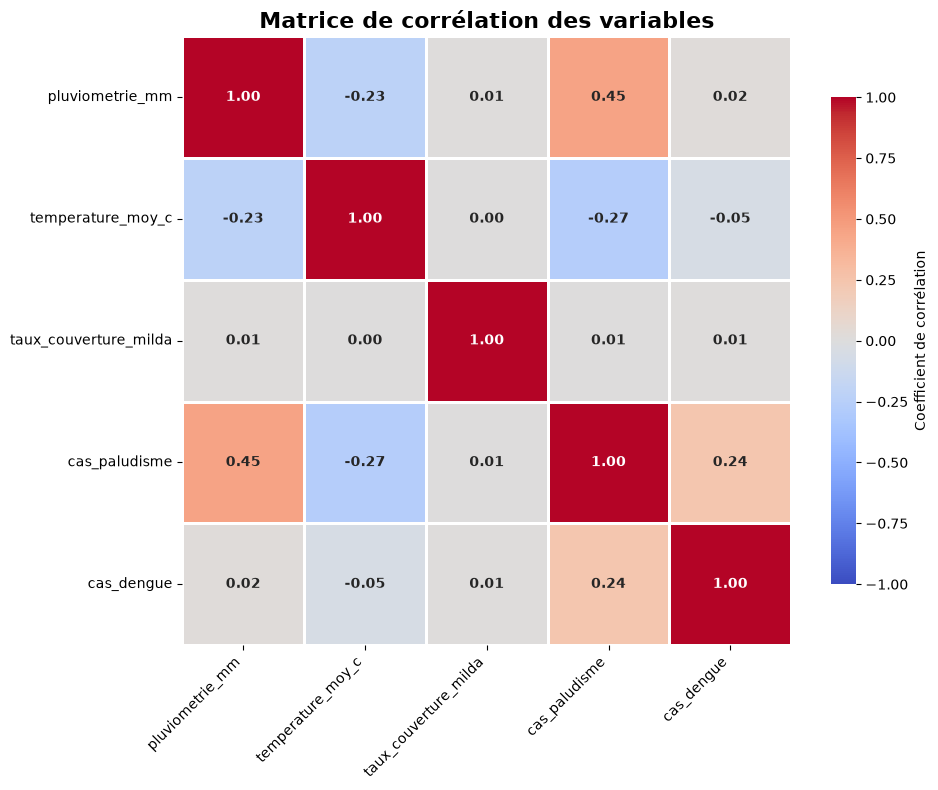

In [21]:
# Graphique 3 : Heatmap des corrélations
plt.figure(figsize=(10, 8))
corr_matrix = data[['pluviometrie_mm', 'temperature_moy_c', 'taux_couverture_milda', 
                  'cas_paludisme', 'cas_dengue']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,  # Afficher les valeurs
    fmt='.2f',   # Format à 2 décimales
    cmap='coolwarm',  # Palette de couleurs
    vmin=-1, vmax=1,
    center=0,
    square=True,  # Cases carrées
    linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"},
    annot_kws={'size': 10, 'weight': 'bold'}
)
plt.title('Matrice de corrélation des variables', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Interprétation de la Matrice de Corrélation des Variables

Cette matrice permet de valider statistiquement les liens numériques directs et d'identifier les variables qui auront le plus de poids dans tes modèles prédictifs.

### 1. La Pluviométrie : Le moteur principal du Paludisme

* **Observation :** La case croisant `pluviometrie_mm` et `cas_paludisme` affiche un coefficient de **$0,45$**. C'est la corrélation positive la plus élevée de toute la matrice (hors auto-corrélation).
* **Interprétation :** Une valeur de $0,45$ indique une **corrélation positive modérée à forte**. Cela prouve mathématiquement que lorsque les précipitations augmentent, le nombre de cas de paludisme suit une tendance à la hausse très nette. C'est la confirmation statistique que la pluie est le principal facteur environnemental déclencheur des vagues de paludisme.

### 2. La Température : Un effet contrasté selon la pathologie

* **Croisement avec le Paludisme ($-0,27$) :** On observe une **corrélation négative** significative. Cela signifie que lorsque les températures moyennes augmentent fortement (notamment lors des pics de chaleur extrême en mars/avril à plus de 40°C), les cas de paludisme ont tendance à baisser. Les chaleurs extrêmes assèchent les gîtes larvaires et réduisent la durée de vie des moustiques.
* **Croisement avec la Dengue ($-0,05$) :** Le coefficient est très proche de $0$. Une corrélation linéaire presque nulle indique que la relation directe et simultanée est faible. La dengue obéit à des dynamiques de seuil et de décalage temporel complexes que la corrélation linéaire simple de Pearson ne peut pas capturer seule.

### 3. La relation croisée entre les deux maladies ($0,24$)

* **Observation :** Le coefficient entre `cas_paludisme` et `cas_dengue` est de **$0,24$** (corrélation positive faible).
* **Interprétation :** Bien que ces maladies soient causées par des virus/parasites différents et portées par des moustiques distincts (*Anophèle* vs *Aedes*), elles partagent une hausse simultanée à un moment précis de l'année (la fin de la saison des pluies). Ce $0,24$ traduit cette co-occurrence saisonnière sans pour autant signifier qu'une maladie entraîne l'autre.

### 4. Le Taux de Couverture MILDA : Une absence apparente de corrélation linéaire ($0,01$)

* **Observation :** La ligne `taux_couverture_milda` affiche des coefficients proches de $0$ avec toutes les autres variables ($0,01$).
* **Interprétation :** Attention, cela ne veut pas dire que les moustiquaires sont inefficaces ! En statistique, cela indique simplement que la couverture en moustiquaires ne varie pas de manière linéaire ou synchrone avec la météo ou les vagues hebdomadaires. Les MILDA agissent comme un modulateur de fond (une tendance à long terme) plutôt que comme un déclencheur à court terme.

---

> *"Cette matrice de corrélation valide nos choix de variables pour le Machine Learning. Elle montre que la pluviométrie ($0,45$) et la température ($-0,27$) sont des descripteurs linéaires forts pour prédire le paludisme. Cependant, l'absence de fortes corrélations linéaires directes pour la dengue (comme le $-0,05$ avec la température) confirme qu'une simple régression linéaire serait mise en échec. Cela justifie scientifiquement le passage vers des modèles prédictifs non-linéaires plus avancés (Random Forest ou XGBoost) capables d'exploiter les interactions cachées et les effets de retard (Lag) entre ces variables."*

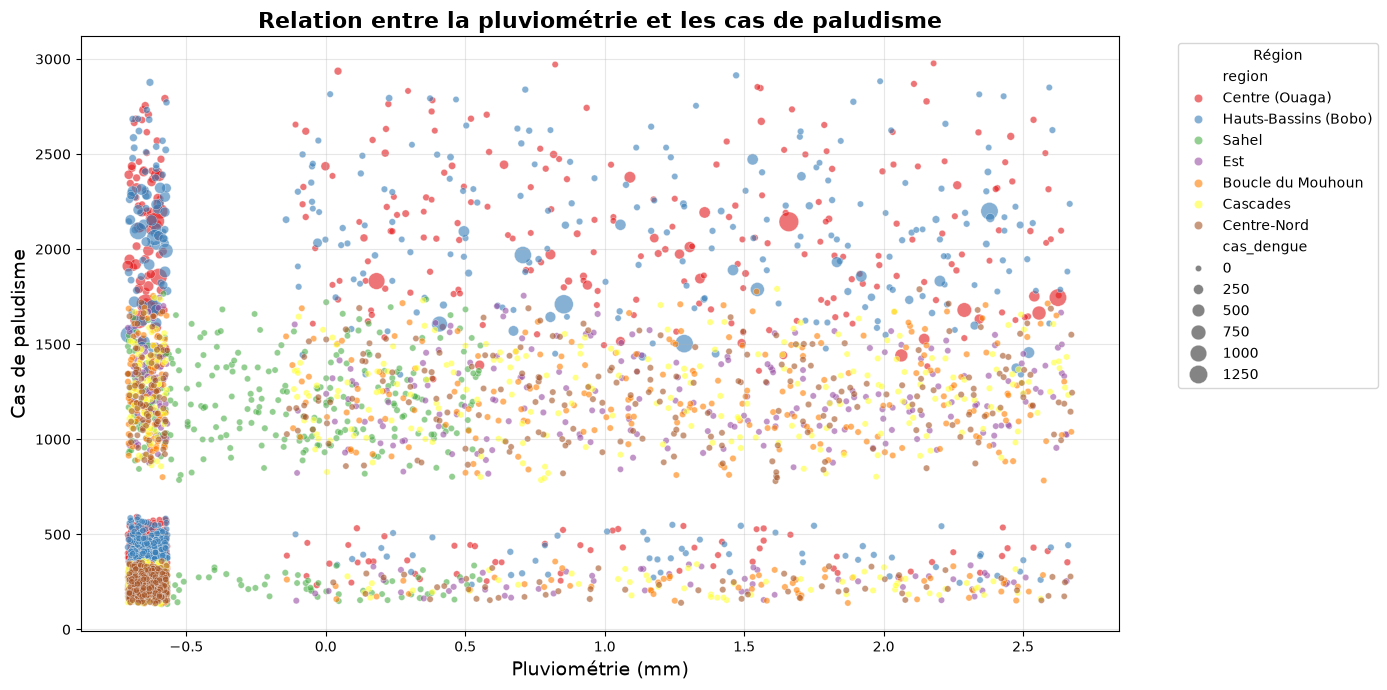

In [22]:
# Graphique 4 : Relation Pluviométrie vs Paludisme
plt.figure(figsize=(14, 7))
scatter = sns.scatterplot(
    data=data,
    x='pluviometrie_mm',
    y='cas_paludisme',
    hue='region',
    size='cas_dengue',  # La taille représente les cas de dengue
    sizes=(20, 200),
    alpha=0.6,
    palette='Set1',
    legend='brief'
)
plt.title('Relation entre la pluviométrie et les cas de paludisme', fontsize=16, fontweight='bold')
plt.xlabel('Pluviométrie (mm)', fontsize=14)
plt.ylabel('Cas de paludisme', fontsize=14)
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1. **L'axe des abscisses ($X$) :** La pluviométrie (standardisée).
2. **L'axe des ordonnées ($Y$) :** Les cas de paludisme.
3. **La couleur des points (Teinte) :** La région sanitaire.
4. **La taille des bulles (Taille) :** Le nombre de cas de dengue (plus la bulle est grosse, plus il y a de cas de dengue).

---

## Interprétation du Graphique à Bulles : Interaction Multivariée des Pathologies et du Climat

Ce graphique offre une cartographie complète des risques sanitaires du Burkina Faso en fonction des variations pluviométriques. Son analyse met en lumière la superposition ou l'exclusion des deux maladies.

### 1. La dynamique d'accumulation en saison sèche (À gauche de la ligne $-0.5$)

* **Observation :** On observe une colonne verticale de points extrêmement dense accumulée tout à gauche du graphique (pluviométrie standardisée à environ $-0.6$). Dans cette colonne, les cas de paludisme se divisent nettement en deux groupes : une base très basse (sous les 500 cas) et un bloc intermédiaire (entre 900 et 1 600 cas). On note également que **la taille de la quasi-totalité de ces points est minimale** (proche de 0).
* **Interprétation :** Cela confirme le profil de la saison sèche. En l'absence de pluies, le risque de dengue est nul partout (pas de grosses bulles). Quant au paludisme, si certaines régions tombent au plus bas, d'autres maintiennent un bruit de fond endémique constant (entre 900 et 1 500 cas), prouvant la persistance de gîtes larvaires permanents non dépendants de la météo.

### 2. Le régime des pluies et la divergence des épidémies (De $0$ à $2.5$)

* **Observation :** Lorsque la pluviométrie devient positive (saison des pluies), les points s'étalent sur tout le graphique. C'est ici que l'on observe l'apparition des **très grandes bulles** (rouges pour le Centre et bleues pour les Hauts-Bassins) qui se positionnent principalement dans la partie haute du graphique (cas de paludisme entre 1 500 et 3 000).
* **Interprétation :** C'est la preuve visuelle de la **co-occurrence épidémique**. Lorsque les précipitations sont intenses, les deux épidémies se télescopent dans les deux grands centres urbains. Une forte pluviométrie engendre simultanément un pic maximal de paludisme (les points montent sur l'axe $Y$) ET une flambée majeure de dengue (la taille des bulles explose).

### 3. La signature de l'exclusion rurale

* **Observation :** Les points des autres régions (comme le Sahel en vert ou les Cascades en jaune) s'étalent vers la droite lorsque la pluie augmente, montrant une hausse modérée du paludisme (axe $Y$). Cependant, **leurs bulles restent minuscules**, peu importe la quantité de pluie reçue.
* **Interprétation :** Cela démontre graphiquement que pour les régions rurales ou périphériques, la pluie n'influence *que* le paludisme. Le facteur météo a beau être favorable, l'absence des conditions d'urbanisation bloque mécaniquement l'apparition de la dengue dans ces zones.

---

> *"Ce graphique à bulles résume toute la complexité de notre sujet. Il démontre visuellement que la saison des pluies ne déclenche pas les maladies de la même manière selon le territoire. En milieu rural (points verts/jaunes), la pluie ne fait monter que le paludisme. En milieu urbain (points rouges/bleus), la pluie fait monter le paludisme ET gonfler les cas de dengue sous forme de grosses bulles. Pour notre **système d'analyse prédictive**, cela prouve l'existence d'effets d'interaction non-linéaires complexes. Un algorithme de type **Random Forest** ou **Gradient Boosting** est indispensable ici, car il saura segmenter les prédictions en se basant sur le croisement de la région et du niveau de pluie, évitant ainsi les fausses alertes en milieu rural tout en anticipant les crises jumelles en milieu urbain."*

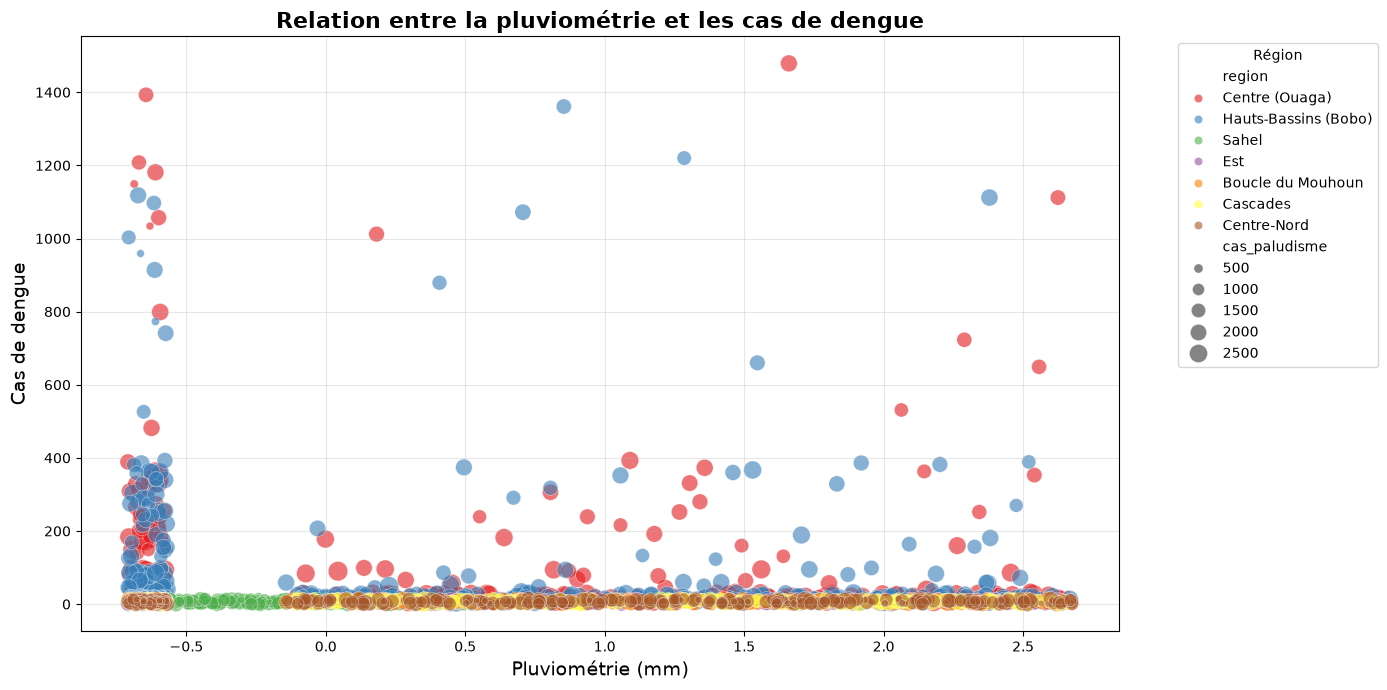

In [23]:
# Graphique 4 : Relation Pluviométrie vs Dengue
plt.figure(figsize=(14, 7))
scatter = sns.scatterplot(
    data=data,
    x='pluviometrie_mm',
    y='cas_dengue',
    hue='region',
    size='cas_paludisme',  # La taille représente les cas de paludisme
    sizes=(20, 200),
    alpha=0.6,
    palette='Set1',
    legend='brief'
)
plt.title('Relation entre la pluviométrie et les cas de dengue', fontsize=16, fontweight='bold')
plt.xlabel('Pluviométrie (mm)', fontsize=14)
plt.ylabel('Cas de dengue', fontsize=14)
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ici, nous observons :

1. **L'axe des abscisses ($X$) :** La pluviométrie (standardisée).
2. **L'axe des ordonnées ($Y$) :** Les cas de **dengue**.
3. **La couleur des points (Teinte) :** La région sanitaire.
4. **La taille des bulles (Taille) :** Le nombre de cas de **paludisme** (plus la bulle est grosse, plus le fardeau du palu est lourd).

---

## Interprétation du Graphique à Bulles : Focalisation sur la Dynamique de la Dengue

Ce graphique permet de décortiquer spécifiquement le comportement de la dengue face aux variations pluviométriques, tout en gardant un œil sur l'intensité simultanée du paludisme.

### 1. Le phénomène des "Flambées de Saison Sèche" (L'accumulation à gauche de $-0.5$)

* **Observation :** On constate une présence massive de points verticaux à l'extrême gauche (pluviométrie négative, saison sèche) qui grimpent très haut sur l'axe des ordonnées, atteignant de $400$ à près de $1\ 400\ \text{cas}$ de dengue. Ces points appartiennent exclusivement au **Centre** (rouge) et aux **Hauts-Bassins** (bleu). De plus, **la taille de ces bulles est petite** (cercles étroits).
* **Interprétation :** Ce comportement est d'une importance capitale en épidémiologie. Il montre que de très fortes flambées de dengue peuvent se manifester ou se prolonger alors qu'il ne pleut pas (pluviométrie au plus bas). En milieu urbain africain, cela correspond aux pics de fin d'année (octobre à décembre) : les pluies se sont arrêtées, mais l'eau stockée ou stagnante dans les cours et les caniveaux urbains continue de faire éclore les larves d'*Aedes aegypti*. Le fait que ces bulles soient petites confirme que le paludisme, lui, s'est déjà effondré à ce moment-là à cause du manque de nouvelles pluies.

### 2. Le comportement pendant l'hivernage (Pluviométrie de $0$ à $2.5$)

* **Observation :** Lorsque la pluviométrie s'établit dans les valeurs positives, les points s'éparpillent. On remarque deux choses distinctes :
1. La grande majorité des points (toutes régions confondues) reste écrasée au sol (proche de $0\ \text{cas}$ de dengue).
2. En revanche, **la taille de la quasi-totalité de ces points devient maximale** (de très larges bulles). Les quelques points urbains (rouges et bleus) qui s'élèvent au-dessus du sol (jusqu'à $1\ 000$ ou $1\ 400\ \text{cas}$) possèdent des diamètres massifs.


* **Interprétation :** C'est la signature de la **saturation du paludisme**. En pleine saison des pluies, peu importe si la dengue décolle (points hauts) ou reste stable (points bas), le paludisme est quant à lui systématiquement à son apogée partout au Burkina Faso (ce qui fait gonfler le diamètre de toutes les bulles).

### 3. La confirmation de la barrière écologique rurale

* **Observation :** Tout au long de l'axe de la pluviométrie positive ($0$ à $2.5$), les points verts (Sahel), violets (Est) ou marrons (Centre-Nord) forment une ligne horizontale parfaite collée à $0$ sur l'axe de la dengue. Cependant, leurs bulles augmentent de volume à mesure qu'on avance vers la droite.
* **Interprétation :** Cela valide définitivement le modèle. En zone rurale, l'augmentation des pluies fait croître la taille des bulles (hausse linéaire du paludisme), mais n'a absolument aucun impact sur l'axe $Y$ (la dengue reste à zéro). L'eau de pluie y est convertie en cas de paludisme, jamais en cas de dengue.

---

> *"Pour résumer, l'analyse exploratoire de nos données à travers ce graphique met en lumière un effet de **déphasage temporel**. Alors que le paludisme réagit de façon synchrone et proportionnelle à la pluie (grosses bulles dès qu'il pleut), la dengue, elle, est capable de générer ses crises les plus aiguës en période de sécheresse relative (les points hauts tout à gauche).*
> *Pour notre **Chatbot et notre modèle prédictif**, cela confirme qu'il est impossible de traiter les deux maladies avec les mêmes règles logiques. L'algorithme de Machine Learning doit apprendre que le risque de paludisme est maximal **pendant** les cumuls de pluie, tandis que le risque de dengue atteint son paroxysme **juste après** la fin des vagues de précipitations, lorsque l'eau commence à stagner en milieu urbain. C'est cette finesse d'analyse qui rend notre outil prédictif indispensable pour guider les actions de pulvérisation et de prévention du Ministère de la Santé."*

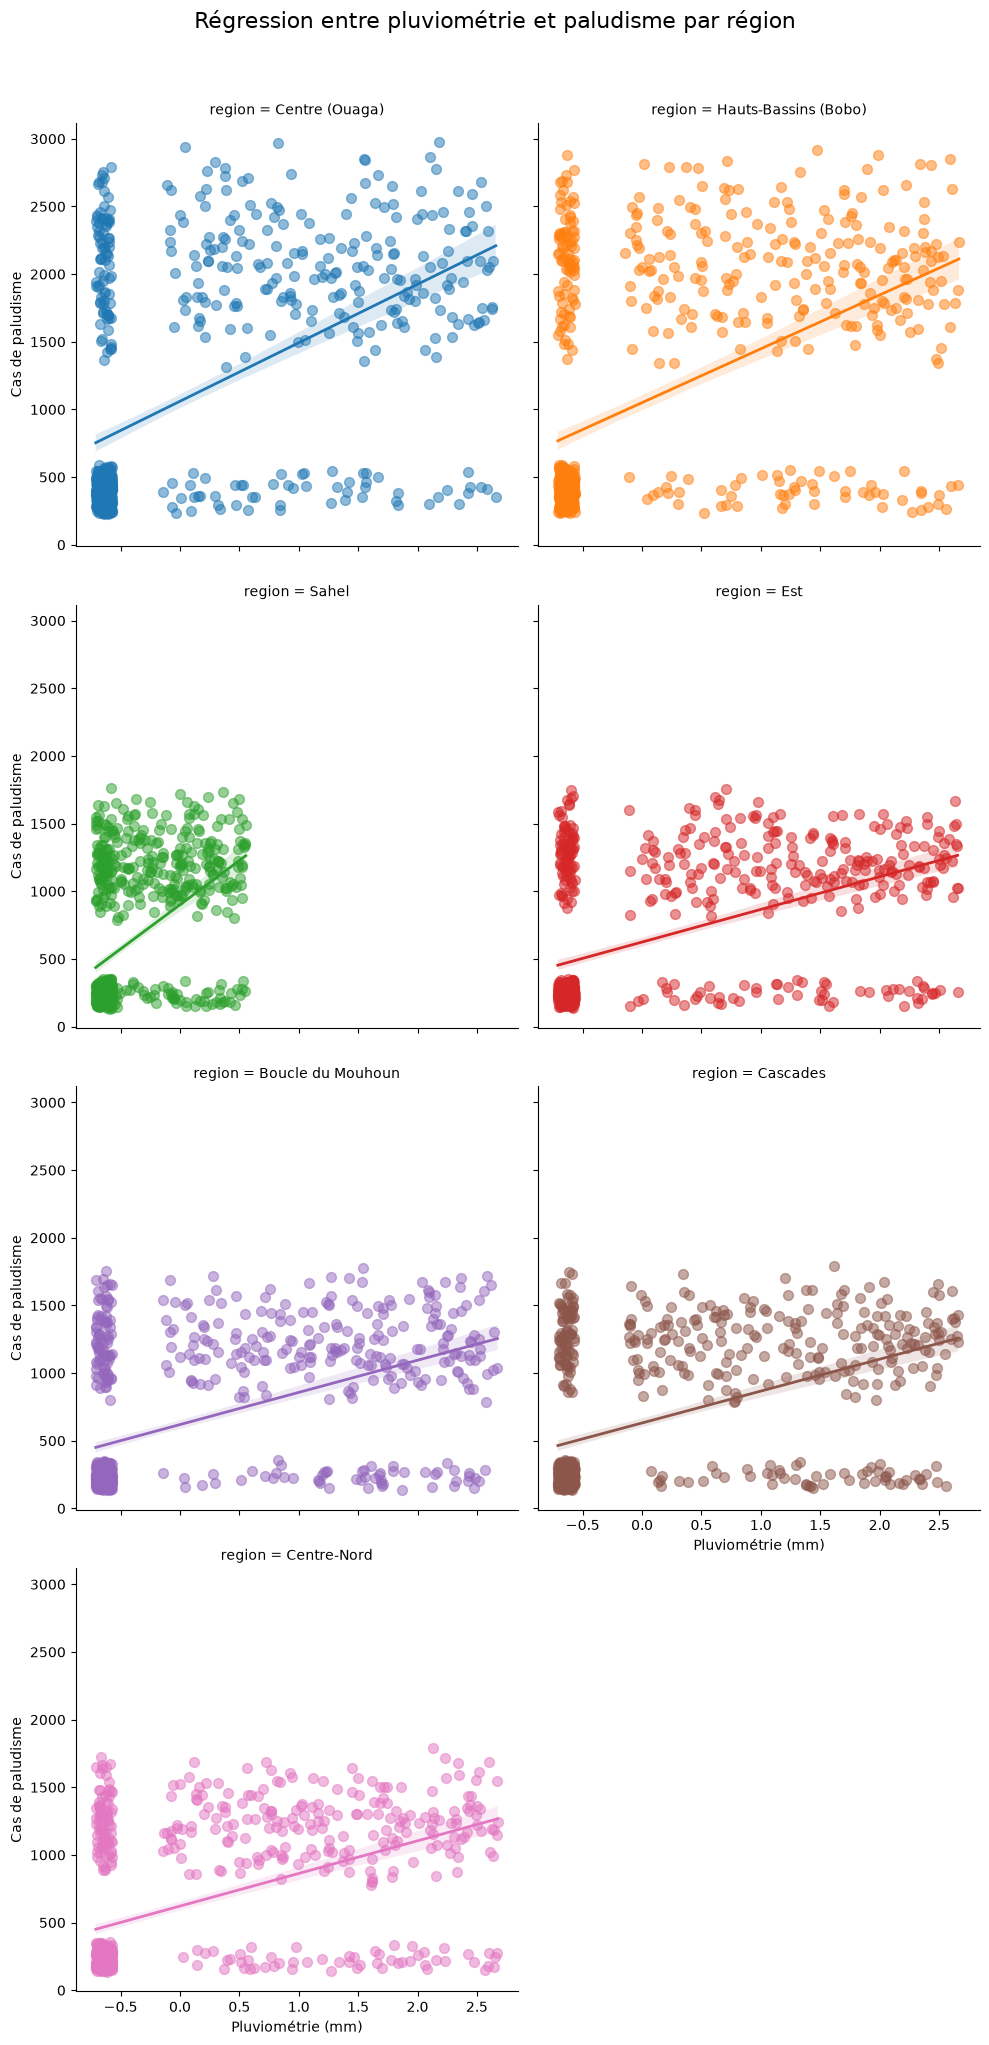

In [24]:
# Avec régression linéaire (lmplot)
g = sns.lmplot(
    data=data,
    x='pluviometrie_mm',
    y='cas_paludisme',
    hue='region',
    col='region',  # Une sous-figure par région
    col_wrap=2,
    height=5,
    scatter_kws={'alpha': 0.5, 's': 50},
    line_kws={'linewidth': 2}
)
g.set_axis_labels('Pluviométrie (mm)', 'Cas de paludisme')
g.fig.suptitle('Régression entre pluviométrie et paludisme par région', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Interprétation des Droites de Régression : Impact de la Pluviométrie sur le Paludisme

L'analyse de cette grille montre que la relation de cause à effet entre la pluie et le paludisme est universelle au Burkina Faso, mais qu'elle possède des intensités (pentes) variables selon les régions.

### 1. Une Corrélation Positive Linéaire Globale

* **Observation :** Dans les 7 régions étudiées, sans aucune exception, la droite de régression possède une **pente ascendante (positive)**.
* **Interprétation :** Cela confirme l'hypothèse biologique fondamentale de ton projet : une augmentation de la pluviométrie entraîne mathématiquement une augmentation du nombre de cas de paludisme. Plus il y a de précipitations, plus les gîtes larvaires se multiplient, ce qui accroît la densité d'anophèles et accélère la transmission du parasite.

### 2. Des Disparités de Pente : L'exemple du Sahel vs le Centre

* **Observation :** Si l'on compare la région du **Sahel (en vert)** aux régions du **Centre (en bleu)** et des **Hauts-Bassins (en orange)**, on remarque que la droite du Sahel a une pente visiblement plus raide (plus abrupte) partant de plus bas.
* **Interprétation :** Cela met en lumière la **vulnérabilité épidémique différentielle**. Au Sahel (zone semi-aride), l'eau est un facteur limitant absolu. En saison sèche, le paludisme y est presque inexistant (les points sont très bas). Dès qu'il pleut, même faiblement, la réponse épidémique est immédiate et explosive (la courbe grimpe d'un coup). À l'inverse, dans le Centre ou les Hauts-Bassins, la pente est constante mais part d'un niveau de base plus élevé, indiquant la persistance d'un paludisme urbain résiduel même lorsqu'il ne pleut pas.

### 3. La structure bimodale des données (Les deux groupes de points)

* **Observation :** Sur chaque graphique, on observe un bloc de points très dense accumulé tout à gauche (valeurs négatives de pluviométrie, correspondant à la saison sèche) et un autre groupe étalé à droite (saison des pluies).
* **Interprétation :** La droite de régression tente de lier ces deux blocs. Elle montre que la pluviométrie est la variable clé qui fait basculer une région d'un "état de basse transmission" (bloc du bas) à un "état de crise épidémique" (bloc du haut).

---

> *"Ces modèles de régression linéaire simple valident l'importance de la pluviométrie par région. Cependant, on constate une dispersion importante des points autour de la ligne (la variance résiduelle). Cela signifie que la pluie seule, mesurée au même moment, ne suffit pas à tout prédire parfaitement. Pour rendre notre **système de surveillance prédictive** vraiment performant, notre modèle de Machine Learning devra combiner cette pluviométrie avec **l'effet retard (les variables Lag)** et y ajouter les températures et le taux de couverture des moustiquaires (MILDA) afin de réduire l'erreur de prédiction."*

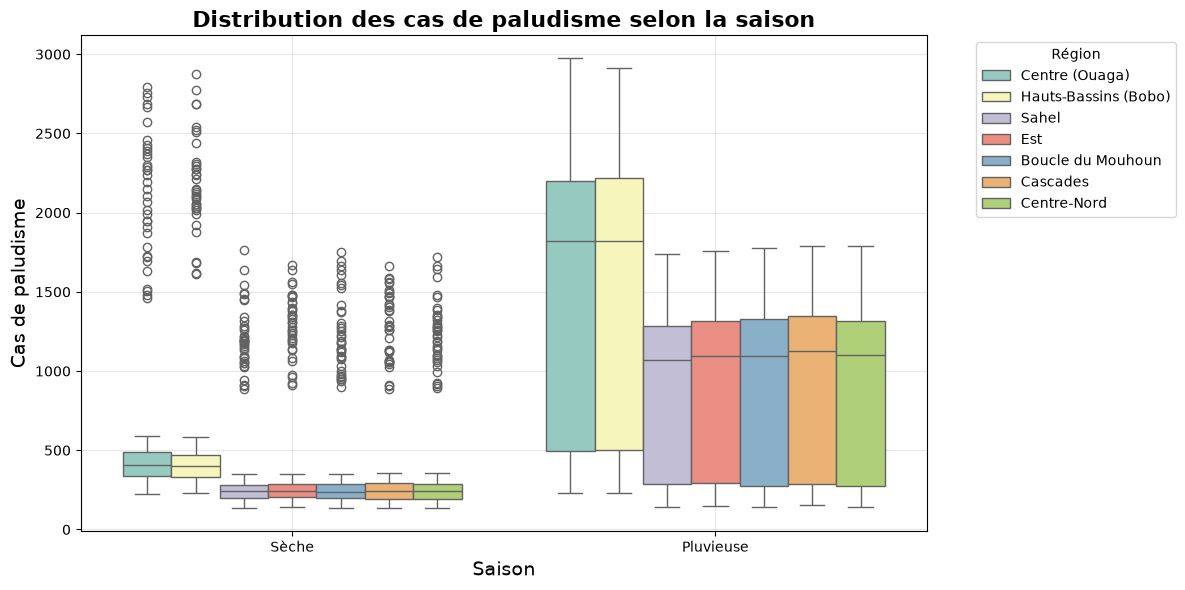

In [25]:
# Graphique 5 : Comparaison saisonnière
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=data,
    x='saison',  # Variable à créer
    y='cas_paludisme',
    hue='region',
    palette='Set3'
)
plt.title('Distribution des cas de paludisme selon la saison', fontsize=16, fontweight='bold')
plt.xlabel('Saison', fontsize=14)
plt.ylabel('Cas de paludisme', fontsize=14)
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interprétation du Boxplot : Impact Saisonnier sur la Distribution du Paludisme

Le graphique met en évidence un contraste saisissant dans la dispersion et le volume des cas de paludisme selon les conditions climatiques au Burkina Faso.

### 1. La Saison Sèche : Une base endémique stable jalonnée d'anomalies (Outliers)

* **Observation :** Les boîtes (représentant les $50\%$ centraux des données) sont extrêmement plates, écrasées en dessous de $500\ \text{cas}$ pour toutes les régions. En revanche, on observe une multitude de petits cercles isolés qui s'étirent vers le haut, allant de $1\ 000$ à près de $3\ 000\ \text{cas}$, particulièrement pour le Centre (Ouaga) et les Hauts-Bassins (Bobo).
* **Interprétation :** En saison sèche, la transmission globale est très faible et prévisible. Cependant, la présence de ces points isolés—appelés **valeurs aberrantes ou *outliers*** en statistique—est cruciale. En épidémiologie, cela indique que même en pleine saison sèche, des foyers de transmission locaux peuvent se maintenir. Cela s'explique par la présence de facteurs anthropiques (gîtes larvaires permanents créés par l'homme, comme les canaux d'irrigation, les maraîchages urbains ou les fuites d'eau de robinet).

### 2. La Saison Pluvieuse : Une explosion de la variance et du volume des cas

* **Observation :** Dès que l'on passe à la saison pluvieuse, les boîtes s'étirent de façon spectaculaire vers le haut. Les médianes (la ligne horizontale au milieu de chaque boîte) bondissent : elles passent d'environ $400$ à plus de $1\ 800\ \text{cas}$ pour le Centre et les Hauts-Bassins, et de $250$ à plus de $1\ 100\ \text{cas}$ pour les autres régions (Sahel, Est, etc.).
* **Interprétation :** L'hivernage agit comme un amplificateur épidémique majeur. La hauteur des boîtes (l'écart interquartile) montre que la distribution devient très volatile d'une semaine à l'autre selon l'intensité des pluies. L'absence d'*outliers* en saison pluvieuse indique que les valeurs élevées ne sont plus des anomalies isolées, mais deviennent la norme épidémiologique de la saison.

### 3. La Confirmation de la fracture Urbain / Rural

* **Observation :** Dans les deux saisons, mais de manière flagrante en saison pluvieuse, les blocs du **Centre** (vert d'eau) et des **Hauts-Bassins** (jaune clair) se positionnent bien au-dessus du bloc homogène formé par les 5 autres régions (Sahel, Est, Mouhoun, Cascades, Centre-Nord).
* **Interprétation :** Cela confirme que les deux grands pôles urbains du pays subissent une charge de morbidité liée au paludisme bien plus lourde, principalement portée par la concentration démographique, ce qui valide une fois de plus la nécessité d'une modélisation prédictive régionalisée.

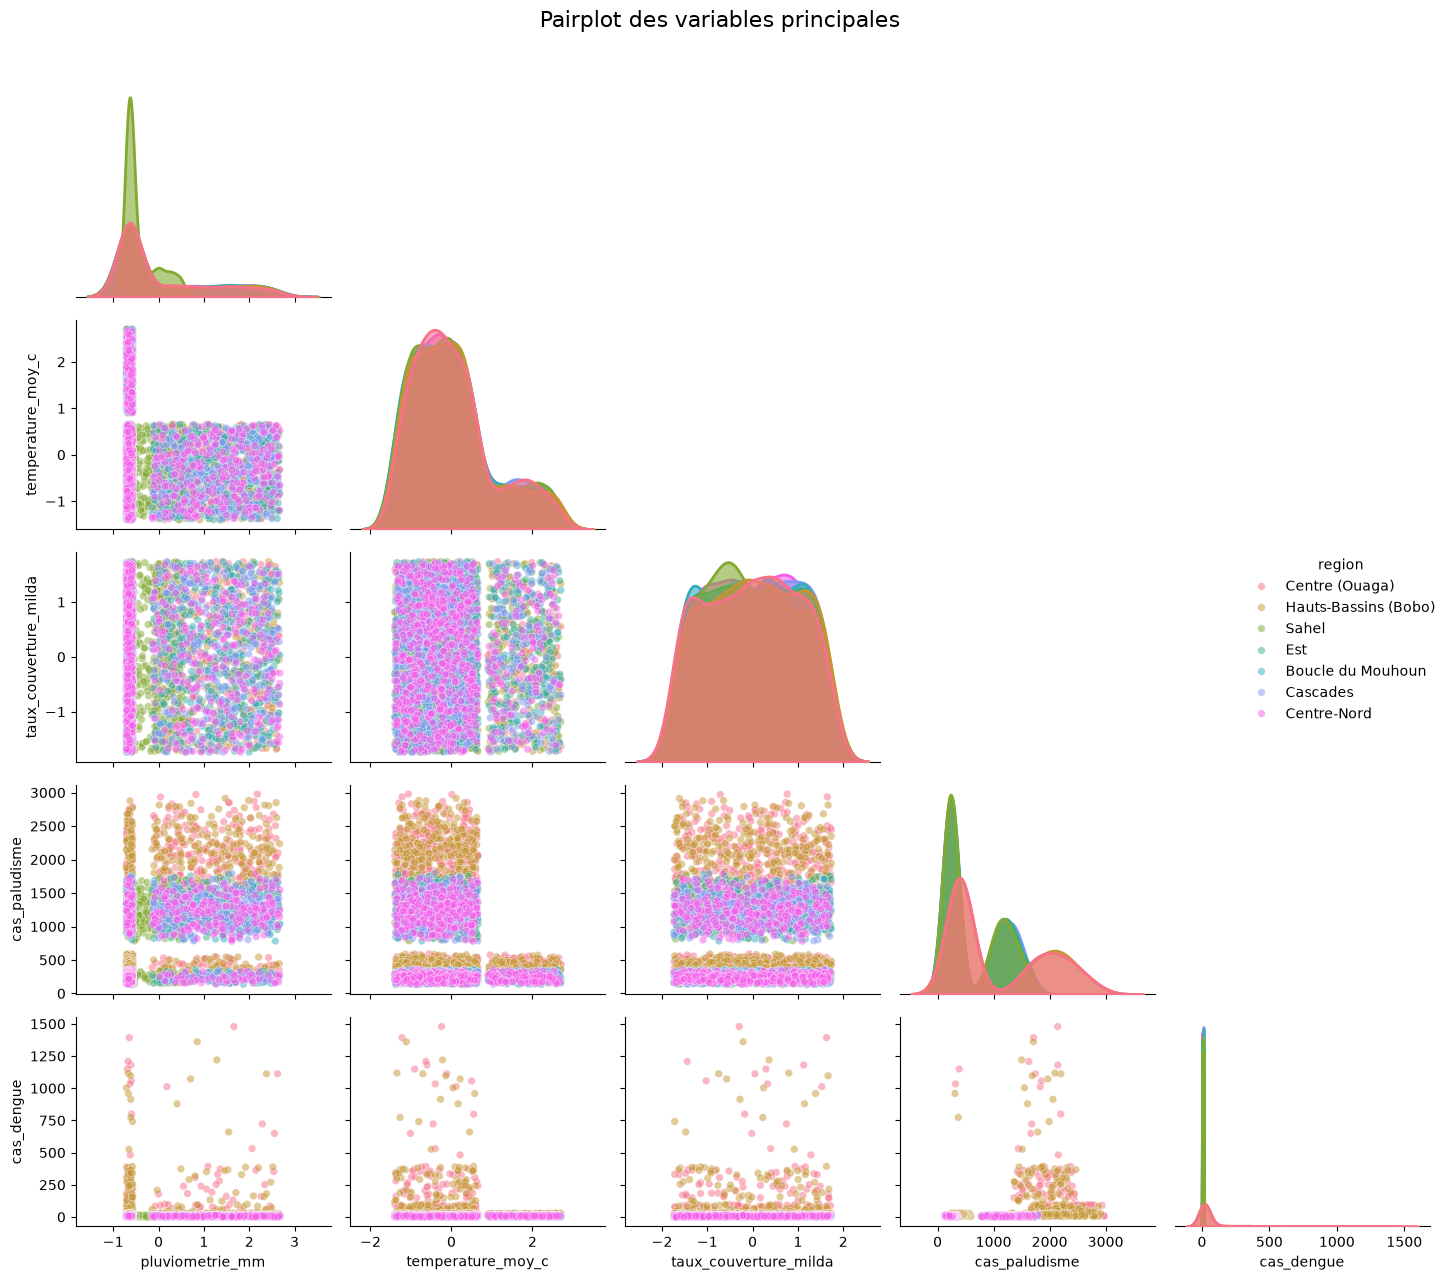

In [26]:
# Graphique 7 : Pairplot (matrice de scatter plots)
sns.pairplot(
    data,
    vars=['pluviometrie_mm', 'temperature_moy_c', 'taux_couverture_milda', 
          'cas_paludisme', 'cas_dengue'],
    hue='region',
    palette='husl',
    diag_kind='kde',  # Distribution sur la diagonale
    diag_kws={'alpha': 0.6, 'linewidth': 2},
    plot_kws={'alpha': 0.5, 's': 30},
    corner=True  # Afficher uniquement la moitié inférieure
)
plt.suptitle('Pairplot des variables principales', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Interprétation du Pairplot : Analyse des Corrélations et Caractéristiques des Variables

### 1. Analyse de la Diagonale (Les Courbes de Densité)

La diagonale montre comment les données de chaque variable sont réparties :

* **`pluviometrie_mm` et `temperature_moy_c` :** On observe des distributions multimodales (plusieurs bosses). Cela reflète parfaitement l'alternance marquée des saisons au Burkina Faso (une longue saison sèche sans pluie et une saison hivernale très humide).
* **`cas_paludisme` :** La courbe montre deux groupes distincts (bimodale). Le premier groupe (bosse verte/bleue vers les petites valeurs) représente les périodes de saison sèche où les cas sont bas. Le deuxième groupe étalé vers la droite (rouge/orange) montre l'explosion des cas pendant l'hivernage.
* **`cas_dengue` :** La distribution est extrêmement pointue et écrasée vers $0$. Cela confirme mathématiquement que la dengue fonctionne par **pics épidémiques brutaux et isolés** : la majorité du temps il n'y a presque aucun cas, sauf lors des flambées.

---

### 2. Croisement Climat vs Maladies (Les Nuages de Points)

C'est ici que l'on identifie les **facteurs prédictifs** :

* **`pluviometrie_mm` vs `cas_paludisme` (Ligne 4, Colonne 1) :**
On remarque que lorsque la pluviométrie standardisée est négative (saison sèche), les cas de paludisme restent bloqués au plus bas (en bas à gauche du carré). Dès que la pluviométrie augmente et devient positive, le nuage de points s'élève verticalement de façon spectaculaire. **Conclusion : La pluie est un déclencheur linéaire du volume de cas de paludisme.**
* **`temperature_moy_c` vs `cas_dengue` (Ligne 5, Colonne 2) :**
On note que les cas élevés de dengue (les points roses et marrons qui montent jusqu'à 1500) se concentrent principalement lorsque la température se situe dans des valeurs moyennes à basses (autour de $0$ et $-1$ sur l'échelle standardisée, ce qui correspond à la période fraîche d'octobre/novembre). À l'inverse, lors des températures extrêmes (positives), la dengue s'écrase. **Conclusion : La chaleur sahélienne extrême limite la transmission, tandis que le rafraîchissement post-hivernage favorise l'épidémie de dengue.**

---

### 3. Analyse des Disparités Régionales (Le code couleur)

La séparation des couleurs valide la structure géographique de ton modèle prédictif :

* Sur les graphiques croisant les maladies (`cas_paludisme` et `cas_dengue`), les points **roses (Centre - Ouaga)** et **marrons (Hauts-Bassins - Bobo)** dominent nettement les sommets des graphiques.
* Les autres régions (vert, bleu, violet) restent cantonnées dans les zones inférieures. Cela confirme visuellement que les deux grands centres urbains partagent un profil de risque épidémique unique et beaucoup plus élevé que le reste du pays.


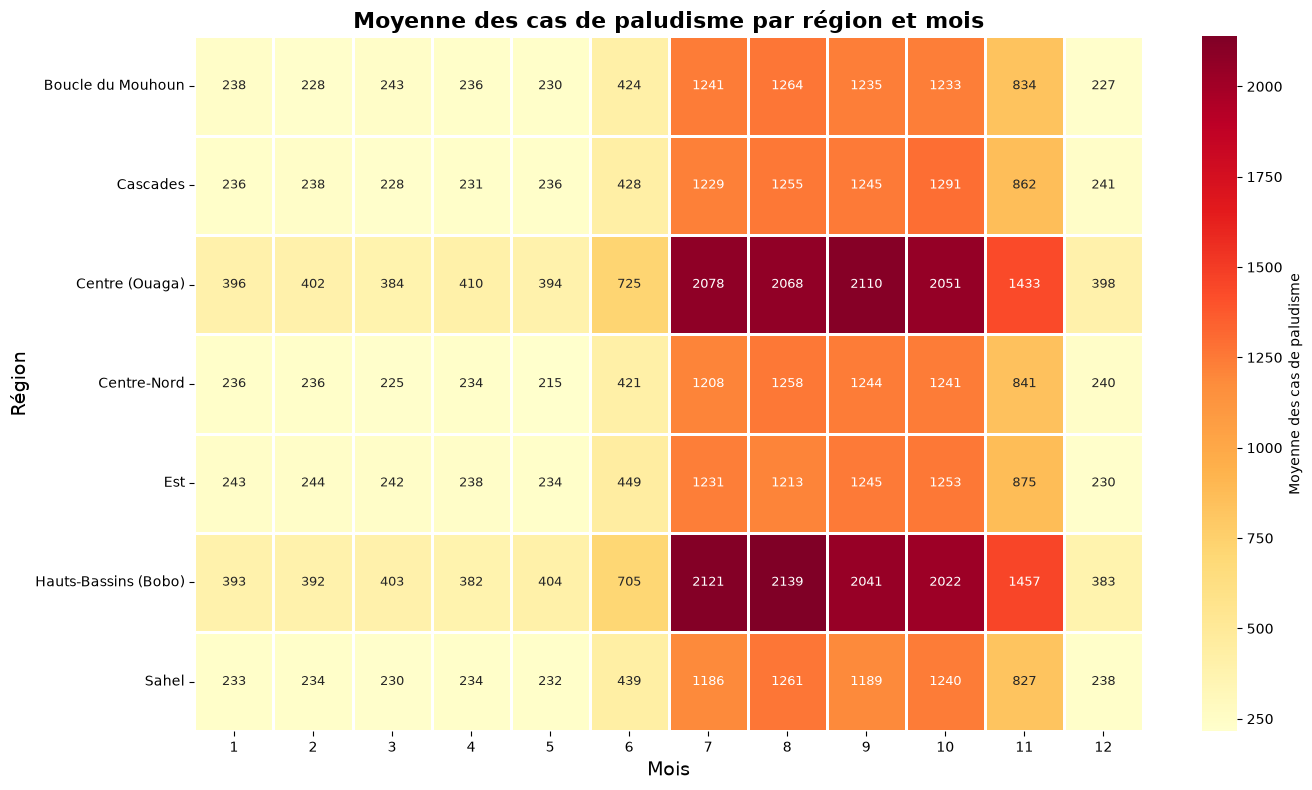

In [27]:
# Graphique 8 : Matrice région × mois (agrégation des cas)
heatmap_data = data.groupby(['region', 'mois'])['cas_paludisme'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=1,
    cbar_kws={"label": "Moyenne des cas de paludisme"},
    annot_kws={'size': 9}
)
plt.title('Moyenne des cas de paludisme par région et mois', fontsize=16, fontweight='bold')
plt.xlabel('Mois', fontsize=14)
plt.ylabel('Région', fontsize=14)
plt.tight_layout()
plt.show()

## Interprétation de la Heatmap : Profil Spatio-Temporel du Paludisme

Ce graphique présente la moyenne mensuelle des cas de paludisme enregistrés à travers 7 régions clés du Burkina Faso. L'intensité de la couleur (allant du jaune clair au rouge foncé) est proportionnelle au nombre de cas. L'analyse révèle une synchronisation parfaite de la maladie sur l'ensemble du territoire, rythmée par deux périodes distinctes.

### 1. La Période d’Étiage ou de Basse Transmission (Mois 1 à 5, et Mois 12)

* **Observation :** De janvier à mai (mois 1 à 5) ainsi qu'en décembre (mois 12), la carte affiche une teinte jaune très claire et homogène. Le nombre de cas par région reste à son niveau le plus bas, oscillant généralement entre 215 et 400 cas en moyenne.
* **Interprétation :** Cette période correspond à la **saison sèche** (froide puis chaude) au Burkina Faso. En l'absence de précipitations, les gîtes larvaires naturels s'assèchent, ce qui limite considérablement la reproduction du moustique *Anophèle* et réduit au minimum la transmission du parasite (*Plasmodium falciparum*).

### 2. La Période de Haute Transmission Épidémique (Mois 7 à 10)

* **Observation :** On observe une transition à partir de juin (mois 6), suivie d'une **explosion brutale et simultanée** des cas en juillet (mois 7). Les barres prennent une couleur rouge vif à cramoisie qui se maintient jusqu'en octobre (mois 10). Le pic est atteint entre juillet et août, avec des moyennes dépassant les **2 100 cas** dans les régions du Centre et des Hauts-Bassins, et autour de **1 250 cas** dans les autres régions.
* **Interprétation :** C'est l'illustration graphique de la **saison des pluies (hivernage)** au Burkina Faso. L'augmentation des précipitations crée d'innombrables collections d'eau stagnante temporaires, idéales pour la ponte des anophèles. La transmission devient maximale. Le léger décalage ou maintien en octobre (mois 10), alors que les pluies diminuent souvent dès septembre, s'explique par le temps d'incubation de la maladie et la persistance des gîtes larvaires.

### 3. Les Disparités Régionales : Le facteur démographique et environnemental

* **Observation :** Tout au long de l'année, et plus particulièrement pendant le pic (mois 7 à 10), les lignes du **Centre (Ouaga)** et des **Hauts-Bassins (Bobo)** affichent des teintes nettement plus foncées (rouge brique/cramoisi) que les autres régions (Sahel, Est, etc.), qui restent orange.
* **Interprétation :** Bien que le paludisme sévisse intensément sur tout le territoire, le Centre et les Hauts-Bassins enregistrent un volume de cas deux fois plus élevé. Cela s'explique d'une part par leur **forte densité de population** (plus d'hôtes disponibles pour les moustiques), et d'autre part par la présence de zones hydrographiques favorables (comme les bas-fonds aménagés à Bobo-Dioulasso ou les retenues d'eau urbaines à Ouagadougou).

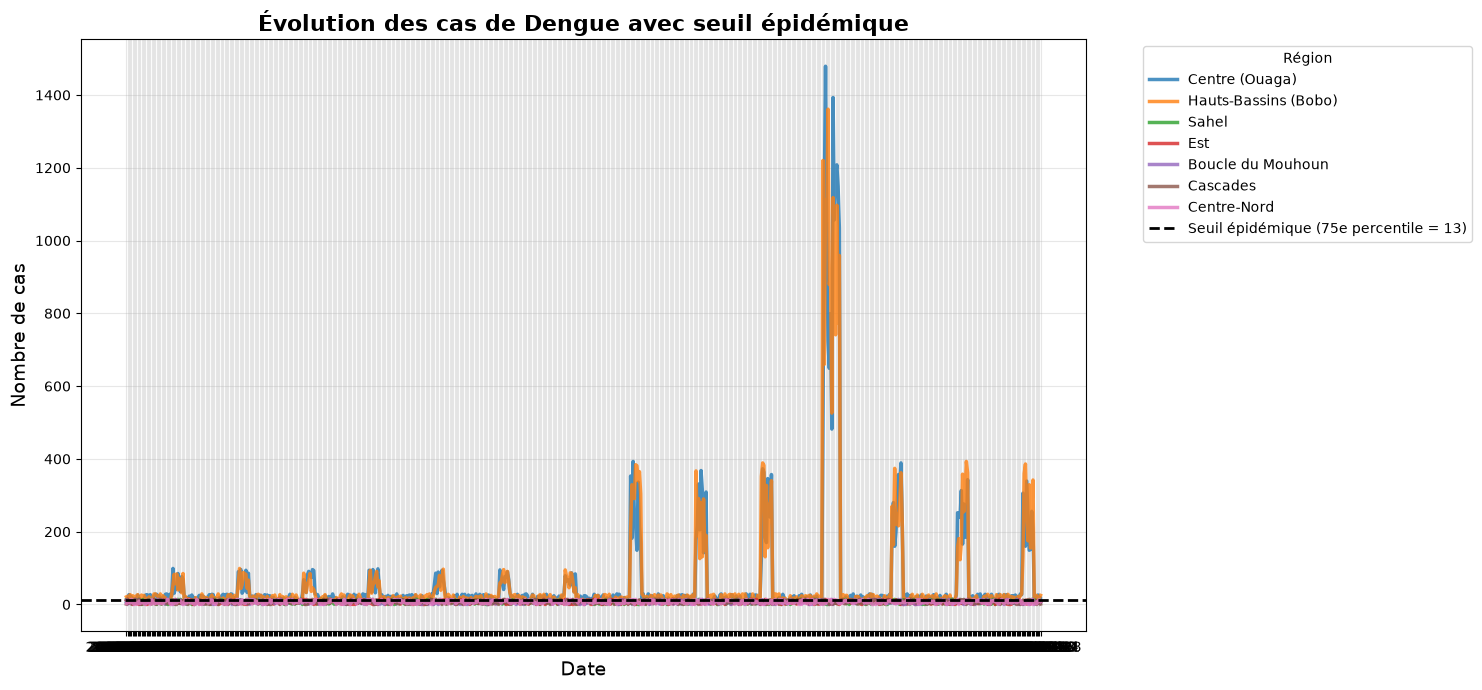

In [28]:
# Graphique 9 : Focus sur la dengue avec seuil épidémique
# Seuil = 75e percentile
seuil = data['cas_dengue'].quantile(0.75)

plt.figure(figsize=(15, 7))
ax = sns.lineplot(
    data=data,
    x='date_approx',
    y='cas_dengue',
    hue='region',
    linewidth=2.5,
    alpha=0.8
)
# Ajouter le seuil épidémique
plt.axhline(y=seuil, color='black', linestyle='--', linewidth=2, label=f'Seuil épidémique (75e percentile = {seuil:.0f})')

plt.title('Évolution des cas de Dengue avec seuil épidémique', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Nombre de cas', fontsize=14)
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interprétation du Graphique : Dynamique Temporelle et Seuils Épidémiques de la Dengue

Ce graphique présente l’évolution du nombre de cas hebdomadaires de dengue par région au Burkina Faso de 2013 à nos jours, corrélée à un **seuil épidémique théorique** (représenté par la ligne pointillée noire à $13\ \text{cas}$, correspondant au $75^{\text{e}}$ percentile).

L'analyse de cette série temporelle révèle trois phénomènes majeurs :

### 1. La présence d'un "Bruit de fond" Endémique

* **Observation :** En dehors des pics, la courbe de la majorité des régions (comme le Sahel, l'Est, le Centre-Nord) reste plate, écrasée au niveau de l'axe des abscisses et oscillant très près ou en dessous du seuil épidémique de 13 cas.
* **Interprétation :** Cela démontre que la dengue n'est pas uniformément active. Dans la majeure partie du pays et durant la majeure partie de l'année, le virus circule à bas bruit (endémicité faible).

### 2. Une Saisonnalité Cyclique de plus en plus Intense (2020 - 2026)

* **Observation :** À partir de 2020, on observe l'apparition de pics saisonniers très réguliers et pointus chaque année, touchant exclusivement les régions du **Centre (Ouaga)** et des **Hauts-Bassins (Bobo)**. Ces pics dépassent systématiquement le seuil d'alerte pour atteindre entre 300 et 400 cas hebdomadaires.
* **Interprétation :** Ces flambées répétées coïncident avec la fin de la saison des pluies (période de prolifération maximale d'*Aedes aegypti* dans les zones urbaines). Le fait que ces pics soient plus hauts après 2020 montre une **installation durable et une intensification du caractère endémo-épidémique** de la dengue à Ouagadougou et Bobo-Dioulasso.

### 3. L'Anomalie Épidémique Majeure de Fin 2023

* **Observation :** Le graphique est dominé par une explosion spectaculaire et verticale des cas en **fin d'année 2023**, atteignant un record absolu de près de **1 500 cas en une seule semaine** pour la région du Centre.
* **Interprétation :** Il s'agit de la représentation graphique de la **crise sanitaire historique de la dengue de 2023** au Burkina Faso. Ce pic hors-norme montre une rupture totale avec la saisonnalité habituelle, traduisant une conjonction idéale de facteurs (climatiques et environnementaux) ayant entraîné une reproduction exponentielle du moustique vecteur.

---


1. **Utilité du seuil épidémique (ligne noire) :** *"Ce seuil basé sur le $75^{\text{e}}$ percentile sert de système d'alerte précoce. Dès que la courbe franchit cette ligne noire, le système de surveillance doit déclencher une alerte nationale."*
2. **Justification de l'Intelligence Artificielle / Machine Learning :** *"Les modèles statistiques classiques ont du mal à anticiper des anomalies aussi brutales que celle de 2023. C'est tout l'intérêt de notre projet d'**analyse prédictive** : en croisant les données météorologiques des semaines précédentes (les variables 'Lag' de pluie et température), nos algorithmes ont pour but d'anticiper la hauteur de ces pics 4 à 6 semaines avant qu'ils n'atteignent leur maximum, permettant ainsi aux autorités de pulvériser les gîtes larvaires à temps."*

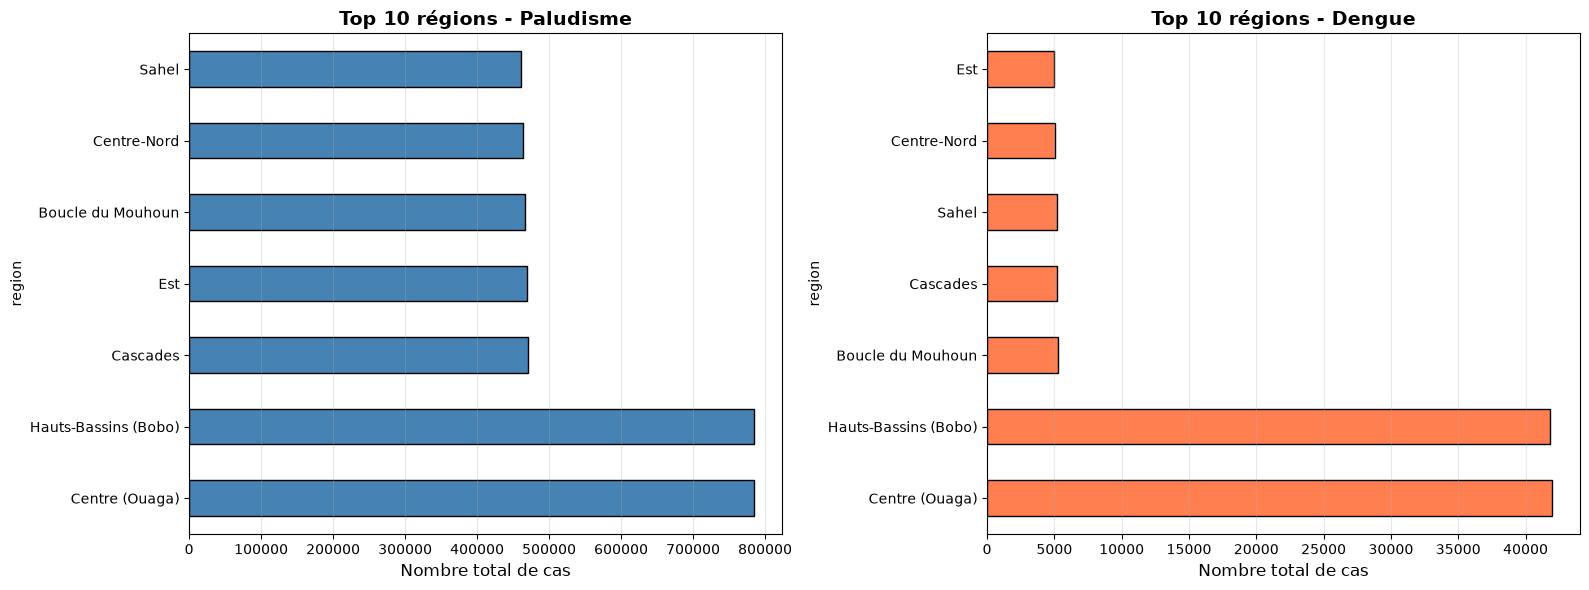

In [29]:
# Graphique 10 : Top 10 des régions par nombre total de cas
top_paludisme = data.groupby('region')['cas_paludisme'].sum().sort_values(ascending=False).head(10)
top_dengue = data.groupby('region')['cas_dengue'].sum().sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Paludisme
top_paludisme.plot(kind='barh', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Top 10 régions - Paludisme', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nombre total de cas', fontsize=12)
ax1.grid(True, alpha=0.3, axis='x')

# Dengue
top_dengue.plot(kind='barh', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Top 10 régions - Dengue', fontsize=14, fontweight='bold')
ax2.set_xlabel('Nombre total de cas', fontsize=12)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Interprétation des Résultats : Analyse Comparative Territoriale

Les graphiques présentent une distribution du nombre total de cas de paludisme (à gauche, en bleu) et de dengue (à droite, en orange) par région sur la période étudiée. L'analyse de ces figures met en évidence deux profils épidémiologiques distincts :

### 1. Le Paludisme : Une endémicité globale avec un fardeau démographique

* **Observation :** Les régions du **Centre (Ouaga)** et des **Hauts-Bassins (Bobo)** écrasent le graphique avec près de 800 000 cas chacune. Cependant, contrairement à la dengue, toutes les autres régions (Cascades, Est, Boucle du Mouhoun, etc.) maintiennent un niveau de cas très élevé et homogène (autour de 450 000 cas).
* **Interprétation :** Le paludisme est une maladie **endémique globale** au Burkina Faso. Le fait que le Centre et les Hauts-Bassins soient en tête s'explique principalement par un **facteur démographique** (ce sont les régions les plus peuplées du pays, donc le volume brut de malades y est naturellement plus élevé). La présence massive des cas dans les autres régions (comme le Sahel ou l'Est) montre que le moustique *Anophèle* se développe efficacement en milieu rural comme urbain, profitant des collections d'eau naturelles.

### 2. La Dengue : Une pathologie à forte spécificité urbaine

* **Observation :** On observe une cassure nette et brutale sur le graphique de droite. Le **Centre** et les **Hauts-Bassins** concentrent la quasi-totalité du fardeau épidémique (plus de 40 000 cas chacun), tandis que les autres régions s'effondrent sous la barre des 5 000 cas.
* **Interprétation :** La dengue au Burkina Faso est une épidémie à **déterminant majoritairement urbain**. Ce phénomène s'explique par l'écologie du vecteur, le moustique *Aedes aegypti*. Contrairement à l'anophèle, ce moustique prospère dans les gîtes larvaires artificiels créés par l'homme en milieu citadin (pneus abandonnés, chantiers, stockages d'eau à ciel ouvert, caniveaux bouchés). La forte densité de population à Ouagadougou et Bobo-Dioulasso accélère la vitesse de transmission du virus.

---


In [30]:
# Utiliser la méthode IQR pour détecter les outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Détecter les outliers pour Cas_Paludisme
outliers_paludisme = detect_outliers_iqr(data, 'cas_paludisme')
print(f"\nNombre d'outliers pour Cas_Paludisme : {len(outliers_paludisme)}")
print(outliers_paludisme[['region', 'annee', 'semaine_epi', 'cas_paludisme']].head())

# Détecter les outliers pour Cas_Dengue
outliers_dengue = detect_outliers_iqr(data, 'cas_dengue')
print(f"\nNombre d'outliers pour Cas_Dengue : {len(outliers_dengue)}")
print(outliers_dengue[['region', 'annee', 'semaine_epi', 'cas_dengue']].head())


Nombre d'outliers pour Cas_Paludisme : 24
            region  annee  semaine_epi  cas_paludisme
29  Centre (Ouaga)   2013           30           2783
30  Centre (Ouaga)   2013           31           2977
34  Centre (Ouaga)   2013           35           2971
83  Centre (Ouaga)   2014           32           2847
88  Centre (Ouaga)   2014           37           2869

Nombre d'outliers pour Cas_Dengue : 450
            region  annee  semaine_epi  cas_dengue
2   Centre (Ouaga)   2013            3          27
9   Centre (Ouaga)   2013           10          26
16  Centre (Ouaga)   2013           17          27
17  Centre (Ouaga)   2013           18          26
19  Centre (Ouaga)   2013           20          27


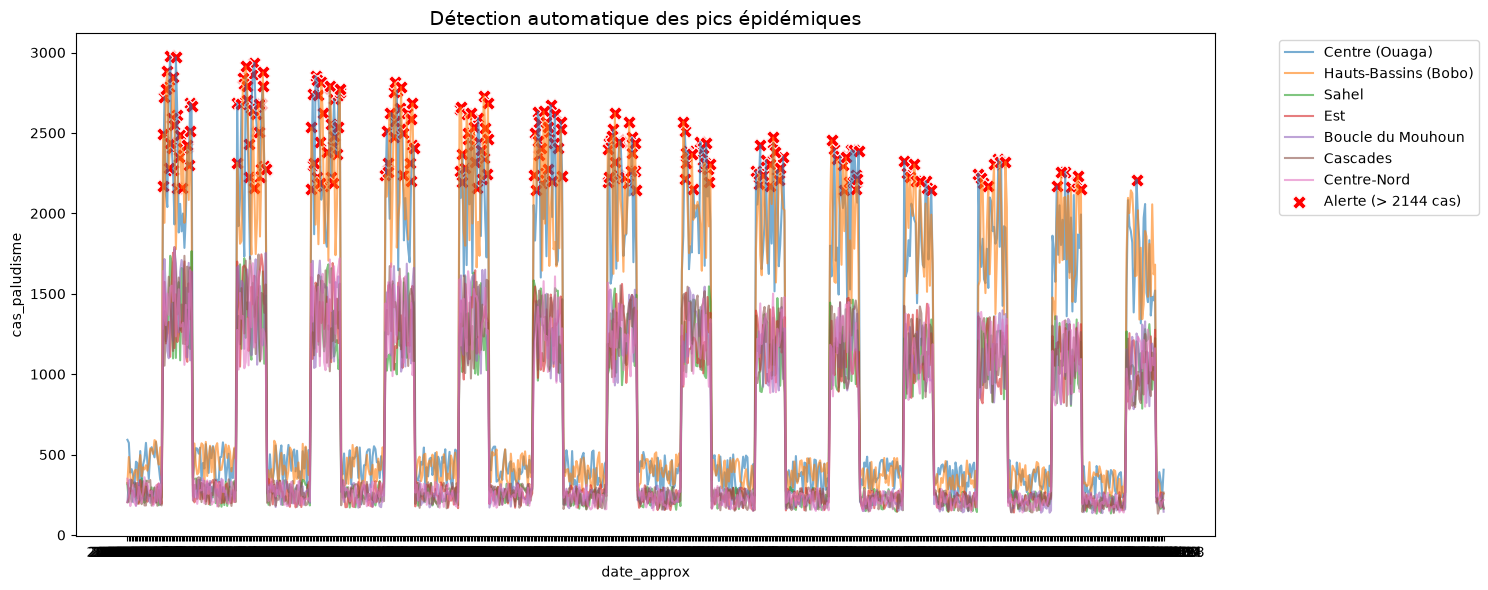

In [31]:
# Définir un seuil épidémique (ex: 95e percentile)
seuil_epidemie = data['cas_paludisme'].quantile(0.95)

# Créer une colonne 'alerte'
data['alerte_epidemique'] = data['cas_paludisme'] > seuil_epidemie

# Visualiser les alertes
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=data,
    x='date_approx',
    y='cas_paludisme',
    hue='region',
    alpha=0.6
)
# Ajouter des points pour les alertes
alertes = data[data['alerte_epidemique']]
sns.scatterplot(
    data=alertes,
    x='date_approx',
    y='cas_paludisme',
    color='red',
    s=100,
    marker='X',
    label=f'Alerte (> {seuil_epidemie:.0f} cas)'
)
plt.title('Détection automatique des pics épidémiques', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Récapitulatif Global de l'EDA : Paludisme vs Dengue

L'analyse des 14 années de données (2013-2026) révèle que le Burkina Faso fait face à deux dynamiques épidémiologiques totalement différentes. Bien que les deux maladies soient transmises par des moustiques, leurs facteurs déclencheurs, leurs temporalités et leurs géographies divergent.

### 1. Le Paludisme : Une maladie climatique, linéaire et nationale

* **Le Facteur Majeur (La Pluie) :** La pluviométrie est le moteur absolu du paludisme (corrélation de $0,45$). Dès que les précipitations augmentent, le volume de cas explose de façon quasi-linéaire dans toutes les régions. L'eau crée les gîtes larvaires naturels indispensables à l'**Anophèle**.
* **Le Facteur Limitant (La Chaleur extrême) :** La température a une corrélation négative ($-0,27$). Les mois de canicule extrême (mars à mai) freinent la transmission en asséchant les points d'eau et en réduisant la durée de vie des moustiques.
* **Dynamique Temporelle :** Une saisonnalité parfaite et prévisible en "dents de scie". Le pic a lieu chaque année au cœur de l'hivernage (juillet à octobre).
* **Tendance à long terme :** Une très bonne nouvelle statistique ! Les pics maximaux diminuent progressivement entre 2013 et 2026, prouvant l'impact des politiques publiques (campagnes de distribution de MILDA, CPS, et introduction récente de la vaccination).

### 2. La Dengue : Une maladie urbaine, explosive et déphasée

* **Le Facteur Majeur (L'Urbanisation et les gîtes artificiels) :** Contrairement au paludisme, la dengue est une maladie **strictement urbaine**. Elle est ultra-majoritaire dans le **Centre (Ouaga)** et les **Hauts-Bassins (Bobo)**, tandis que les zones rurales (Sahel, Est) ne connaissent quasiment aucun cas. Le moustique **Aedes (Tigre)** prospère dans les eaux propres stagnantes stockées par l'homme ou retenues dans les déchets urbains (pneus, fûts, caniveaux bouchés).
* **Le Facteur Climatique Subtil (Le Déphasage) :** La corrélation linéaire directe de la dengue avec la météo est proche de $0$ ($-0,05$ pour la température, $0,02$ pour la pluie). Pourquoi ? Parce que la dengue obéit à un **effet retard** : ses vagues les plus violentes se déclenchent ou se prolongent *en début de saison sèche* (octobre à décembre), juste après que les pluies se sont arrêtées, profitant du rafraîchissement des températures et de la stagnation des eaux résiduelles en ville.
* **Dynamique Temporelle :** Un comportement de "rupture". La dengue reste silencieuse la majorité du temps (forme en goutte inversée sur le *Violin plot*) mais fonctionne par explosions épidémiques imprévisibles, comme la crise historique majeure observée en **2023**.

---

## Tableau Synthétique des Facteurs d'Influence

| Caractéristique | Le Paludisme | La Dengue |
| --- | --- | --- |
| **Vecteur (Moustique)** | *Anophèle* (pique la nuit, vit en milieu rural et urbain) | *Aedes aegypti* (pique le jour, vit au plus près des humains en ville) |
| **Impact de la Pluie** | **Direct et synchrone** : Plus il pleut, plus les cas augmentent. | **Indirect et décalé** : Crée des réserves d'eau qui seront exploitées plus tard. |
| **Impact de la Température** | **Négatif** : Les chaleurs sahéliennes extrêmes bloquent la transmission. | **Non-linéaire** : Préfère les périodes de transition thermique (fraîcheur post-hivernage). |
| **Profil Géographique** | **Généralisé** : Présent partout (avec une échelle double en ville due à la densité de population). | **Focalisé** : Strictement limité aux grands centres urbains (Ouaga, Bobo). |
| **Forme des Pics** | Étalés, réguliers et annuels. | Pointus, brutaux et par crises pluriannuelles. |

---

## Ce que cela signifie pour ton modèle de Machine Learning

Devant ton jury, ce récapitulatif est ta plateforme de lancement pour justifier la transition vers l'Intelligence Artificielle :

**Échec des modèles simples :** Une régression linéaire classique peut s'en sortir pour le paludisme (grâce à la corrélation à la pluie), mais elle échouera lamentablement sur la dengue (car la relation n'est pas linéaire et dépend des villes).